In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "scripts"))

import plotting_utils as pu
import directories as dirs

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import arviz as az
import ast

import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

results:   0%|          | 0/5 [00:00<?, ?it/s]

PE

In [33]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1155_inclined/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [27]:
imed = np.argmin(np.abs(pe_df['H1_time'] - np.mean(pe_df['H1_time'])))
imed

np.int64(2808)

1126259462.437966
0.0002480066504549042 0.00024888228641274386


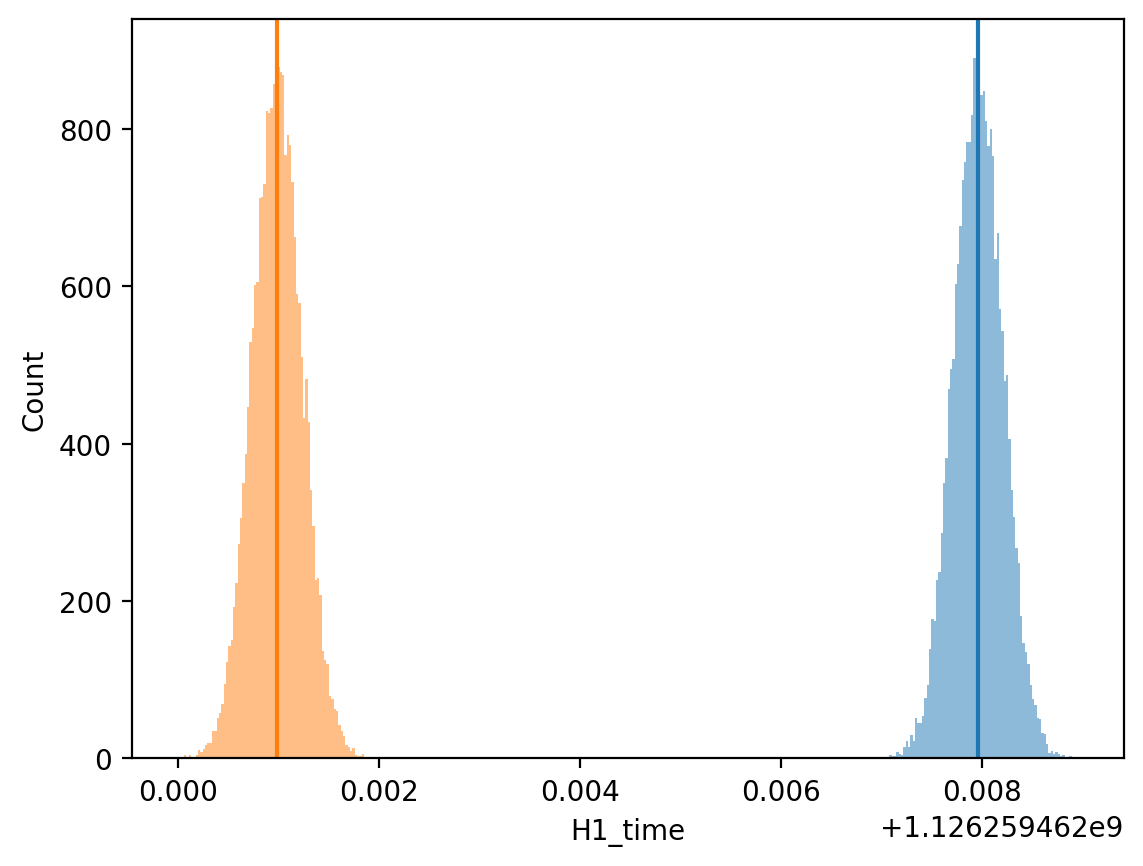

In [28]:
sns.histplot(pe_df, x='H1_time', element='step', lw=0, alpha=0.5)
sns.histplot(pe_df, x='L1_time', element='step', lw=0, alpha=0.5)
print(np.median(pe_df['H1_time']))
print(np.std(pe_df['H1_time']), np.std(pe_df['L1_time']))

plt.axvline(pe_df['H1_time'][imed], color='C0')
plt.axvline(pe_df['L1_time'][imed], color='C1')

In [34]:
pe_df['phase'] = pe_df['phase'] % (2*np.pi)

In [31]:
pe_df

,mass_ratio,chirp_mass,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,dec,ra,...,psi_J,final_mass,final_spin,final_kick,peak_luminosity_non_evolved,cos_tilt_1,cos_tilt_2,cos_theta_jn,viewing_angle,cos_iota
0,0.981857,156.120967,0.648172,0.593428,1.544333,1.215658,1.434923,4.115454,-1.041544,0.642953,...,4.699036,339.535677,0.738187,425.765626,3.904953,0.026460,0.347720,-0.788269,0.662806,-0.901214
1,0.892338,157.335750,0.788576,0.456345,1.156901,1.031702,2.940351,2.785650,-1.194599,3.052391,...,2.281672,341.171088,0.771934,1874.026107,4.231297,0.402179,0.513359,-0.473529,1.077503,-0.426567
2,0.985912,137.482614,0.122145,0.275581,0.821067,2.460452,3.573485,2.753550,-1.295039,1.991064,...,3.912637,301.067359,0.667355,204.234775,3.610939,0.681440,-0.776855,0.575113,0.958054,0.585600
3,0.926221,142.516138,0.170674,0.435780,2.677501,1.564336,0.560519,5.418620,-1.204720,3.327155,...,1.947353,312.511846,0.669673,77.339050,3.569047,-0.894229,0.006460,-0.630208,0.888975,-0.723080
4,0.992667,138.497097,0.330462,0.005146,1.940727,2.719864,0.428925,5.740259,-0.709996,3.026914,...,2.627425,303.292744,0.671543,91.426122,3.610682,-0.361551,-0.912383,0.488331,1.060620,0.434391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21372,0.938491,145.896041,0.316065,0.038922,1.560340,2.533341,1.416545,3.267927,-1.250281,2.321507,...,3.639703,319.244869,0.684805,387.807009,3.680767,0.010456,-0.820648,0.556566,0.980549,0.540042
21373,0.992172,146.484667,0.010187,0.013934,1.416226,0.842270,2.217796,3.987221,-1.206501,2.378656,...,3.507743,320.192442,0.688176,4.607263,3.719970,0.153955,0.665771,0.535330,1.005898,0.533313
21374,0.983973,141.929095,0.055358,0.038681,0.320802,1.896967,0.811220,5.153176,-1.237050,2.287391,...,3.586430,310.115430,0.692852,13.015663,3.745319,0.948983,-0.320418,0.479832,1.070333,0.466127
21375,0.937500,144.236713,0.251005,0.015689,1.963918,2.311549,0.861568,3.908405,-1.247561,2.359706,...,3.485233,315.991303,0.669986,388.920214,3.611198,-0.383074,-0.674843,0.652891,0.859402,0.601585


<Axes: xlabel='final_mass', ylabel='final_spin'>

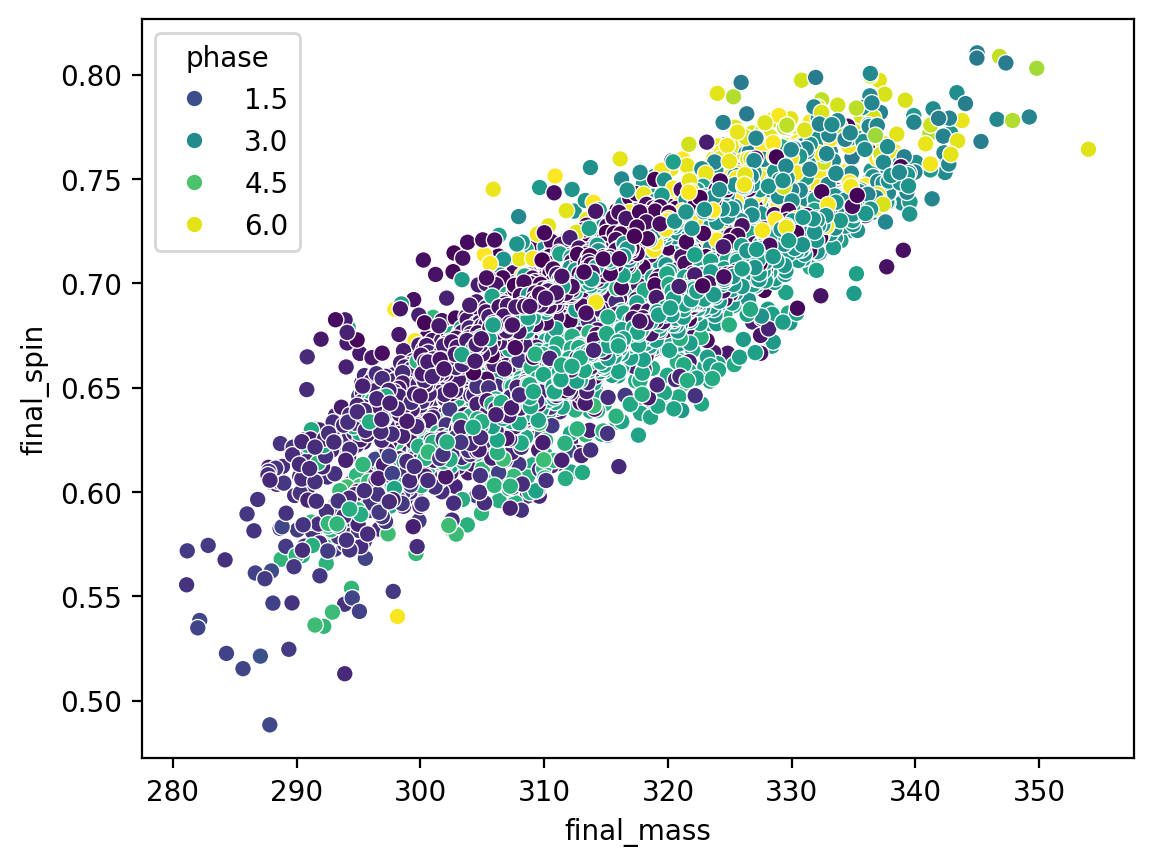

In [35]:
sns.scatterplot(pe_df, x='final_mass', y='final_spin', hue='phase', palette='viridis')
# sns.kdeplot(pe_df, x='final_mass', y='final_spin', levels=[0.1])
# plt.scatter(x=[pe_df['final_mass'].iloc[imed]], y=[pe_df['final_spin'].iloc[imed]], color='C1')

In [40]:
fit_light_p = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_faceon/engine/1126259462.423000/config.ini')
config = ast.literal_eval(fit_light_p.attrs['config'])
TM = rd.qnms.T_MSUN * float(config['model']['m_min']) * 2

In [41]:
(pe_df['H1_time'][imed] - fit_light_p.start_times['H1']) / TM, (pe_df['L1_time'][imed] - fit_light_p.start_times['L1']) / TM

(np.float64(0.791462233482541), np.float64(0.8073467285698869))

Comparing inferred remnant spins from inclined injections for both system masses:

In [ ]:
fit_l = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined/engine/1126259462.423000/config.ini')
fit_h = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/1126259462.423000/config.ini')

In [ ]:
(fit_h.start_times['L1'] - np.median(pe_df['L1_time'].iloc[imed])) /(rd.qnms.T_MSUN * 321)

np.float64(1.3357377922181135)

In [ ]:
fit_h.start_times

{'H1': 1126259462.437694, 'L1': 1126259462.4307084}

In [ ]:
coll_l = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined/engine/*/result.nc')
coll_h = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
mf_l = coll_l[0].config['model']['m_min'] * 2
mf_h = coll_h[0].config['model']['m_min'] * 2

mf_l, mf_h

(70.0882137, 321.23764612)

In [ ]:
coll_l.reindex_by_t0(reference_time=1126259462.423, reference_mass=mf_l, decimals=0)
coll_h.reindex_by_t0(reference_time=1126259462.423, reference_mass=mf_h, decimals=0)

In [ ]:
df_l = coll_l.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
df_h = coll_h.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
# end = 12

# g = sns.histplot(df_l[df_l['run']<=end], x='chi', hue='run', palette=sns.color_palette('Oranges', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, element='step', stat='density', legend=False, bins=30)
# sns.histplot(df_h[df_h['run']<=end], x='chi', hue='run', palette=sns.color_palette('Oranges', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, element='step', alpha=0, stat='density', legend=False, bins=30)

# g.legend(list(g.collections), df_l['run'].unique(), frameon=False, title='start time [M]', ncol=2)
# plt.xlabel('$\chi_{\mathrm{f}}$')

Text(0.5, 1.0, 'SXS_BBH_1156 (inclined) fit w/ Kerr 220+210')

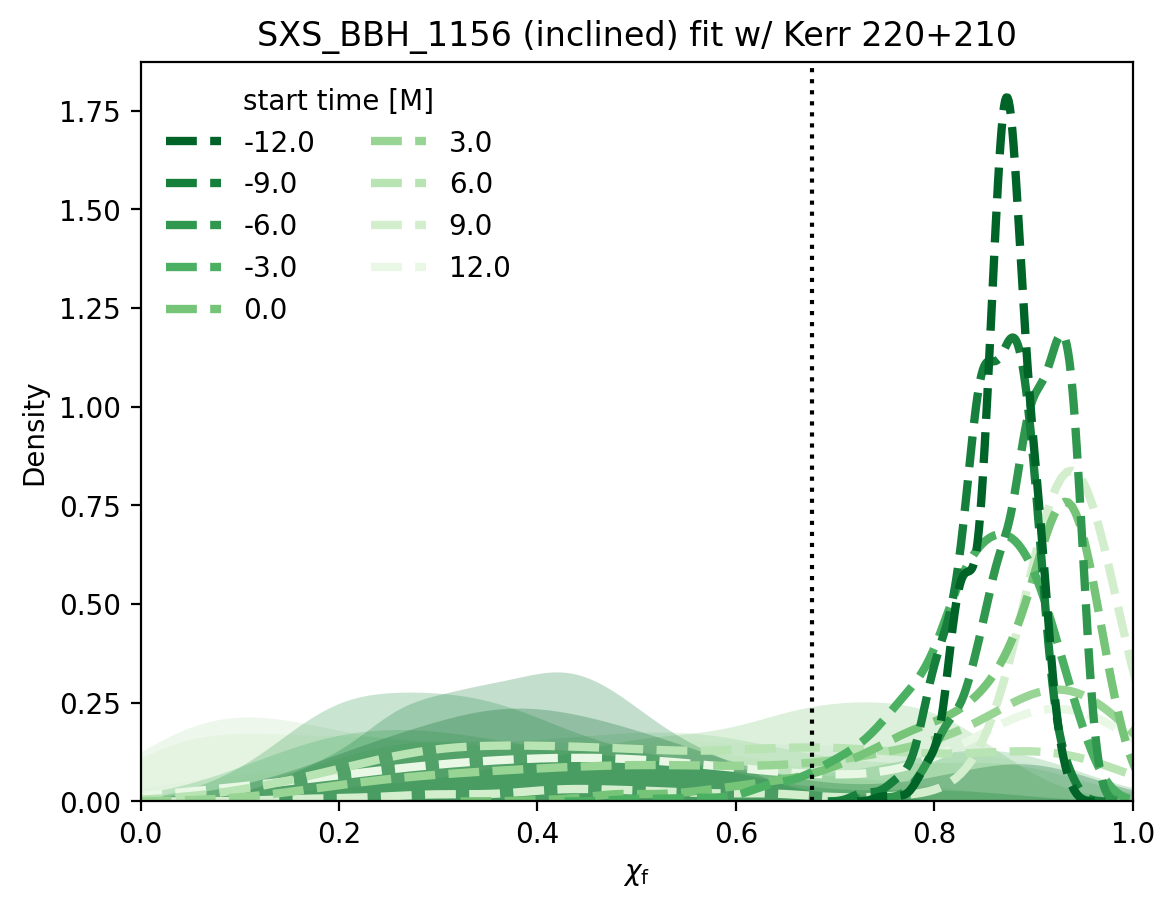

In [ ]:
end = 12

sns.kdeplot(df_l[df_l['run']<=end], x='chi', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, fill=True, legend=False)
g = sns.kdeplot(df_h[df_h['run']<=end], x='chi', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, ls='--', fill=False)

g.legend(list(g.get_lines())[::-1], df_l['run'].unique(), frameon=False, title='start time [M]', ncol=2)
plt.xlabel('$\chi_{\mathrm{f}}$')

plt.xlim(0,1)
plt.axvline(0.67721823, c='k', ls=':')
plt.title('SXS_BBH_1156 (inclined) fit w/ Kerr 220+210')

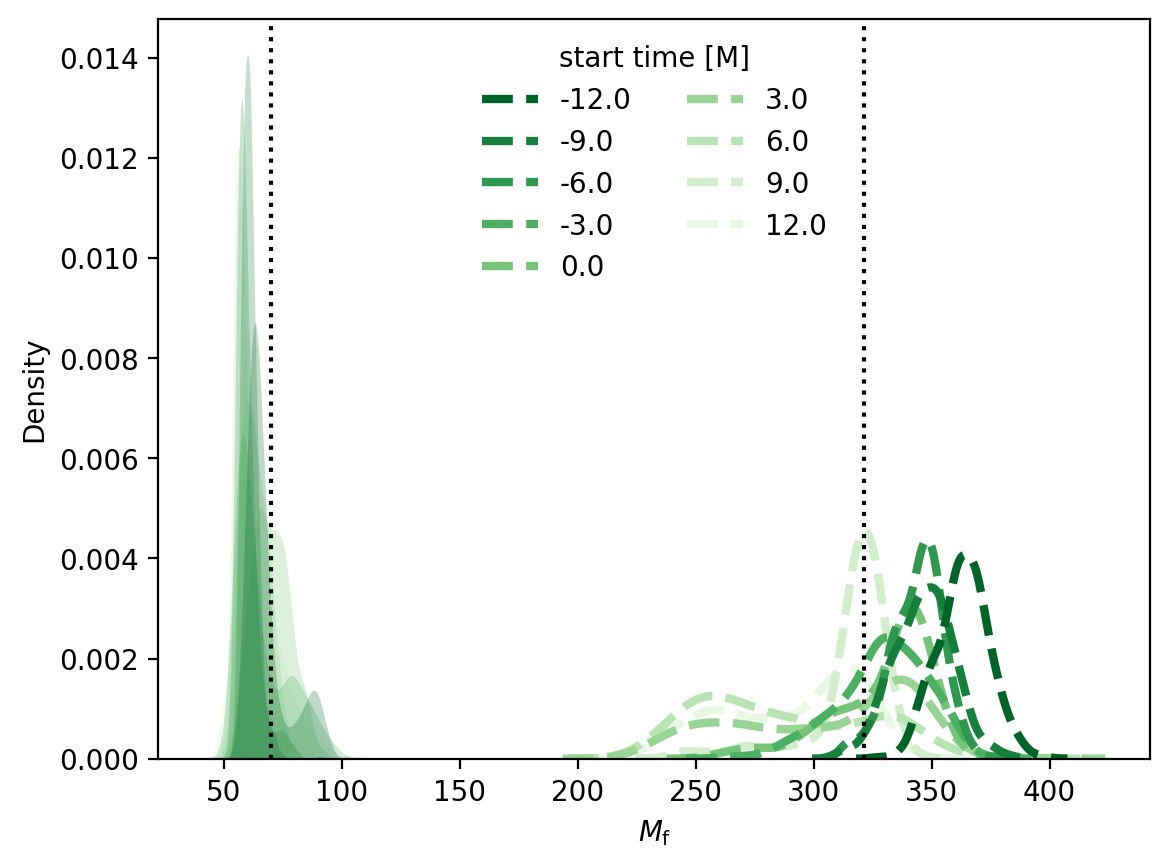

In [ ]:
end = 12

sns.kdeplot(df_l[df_l['run']<=end], x='m', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_l[df_l['run']<=end]['run'].unique())), linewidth=0, fill=True, legend=False)
g = sns.kdeplot(df_h[df_h['run']<=end], x='m', hue='run', palette=sns.color_palette('Greens_r', n_colors=len(df_h[df_h['run']<=end]['run'].unique())), linewidth=3, ls='--', fill=False)

g.legend(list(g.get_lines())[::-1], df_l['run'].unique(), frameon=False, title='start time [M]', ncol=2)
plt.xlabel('$M_{\mathrm{f}}$')

plt.axvline(mf_l, color='k', ls=':')
plt.axvline(mf_h, color='k', ls=':')

### beyond-GR

In [ ]:
collo = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/tgr/220+d221_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')
collf = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/tgr/220+d210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
collo.reindex_by_t0(reference_time=1126259462.423, reference_mass=collo[0].config['model']['m_min'] * 2, decimals=0)
collf.reindex_by_t0(reference_time=1126259462.423, reference_mass=collo[0].config['model']['m_min'] * 2, decimals=0)

In [ ]:
dfo = collo.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
dff = collf.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

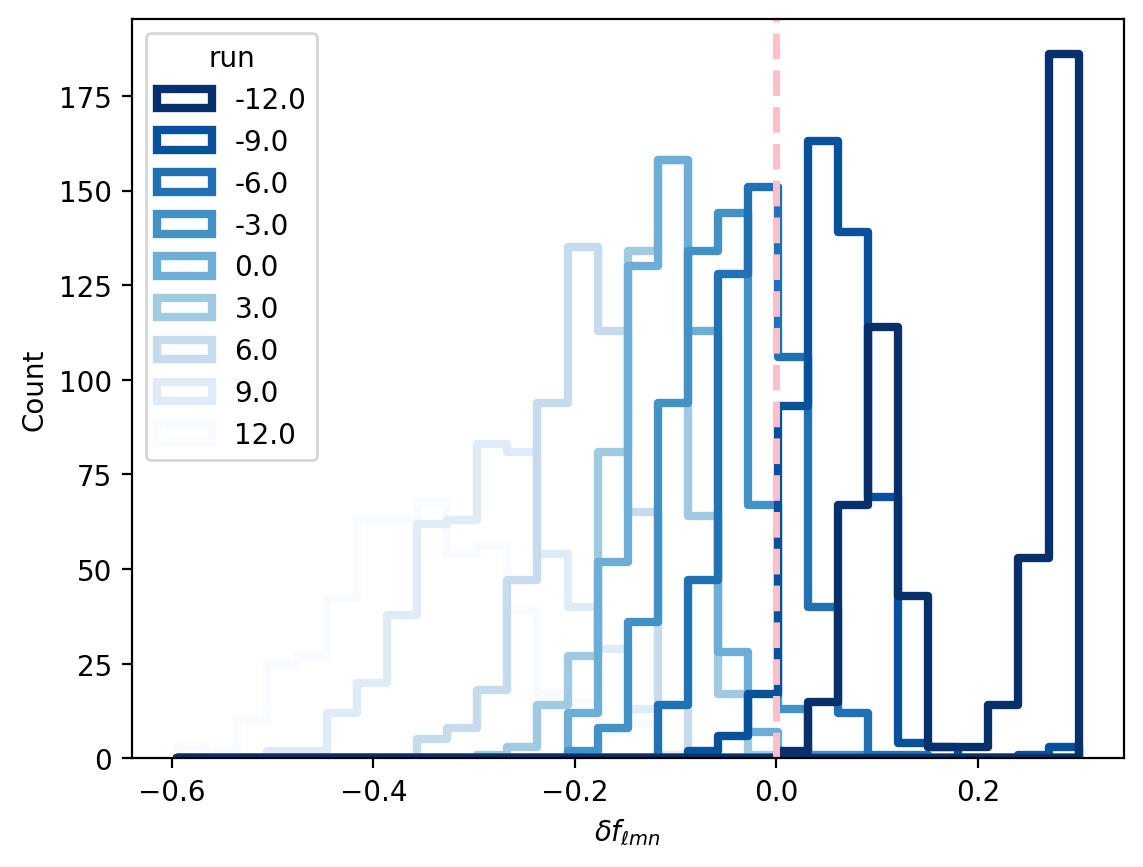

In [ ]:
# sns.histplot(dfo, x='df_221', element='step', alpha=0, palette='Oranges_r', hue='run', lw=3, bins=30)
sns.histplot(dff, x='df_210', element='step', alpha=0, palette='Blues_r', hue='run', lw=3, bins=30)

plt.xlabel('$\delta f_{\ell m n}$')

plt.axvline(0, ls='--', color='pink', lw=2.5)

Text(0.5, 0, '$\\delta \\gamma_{\\ell m n}$')

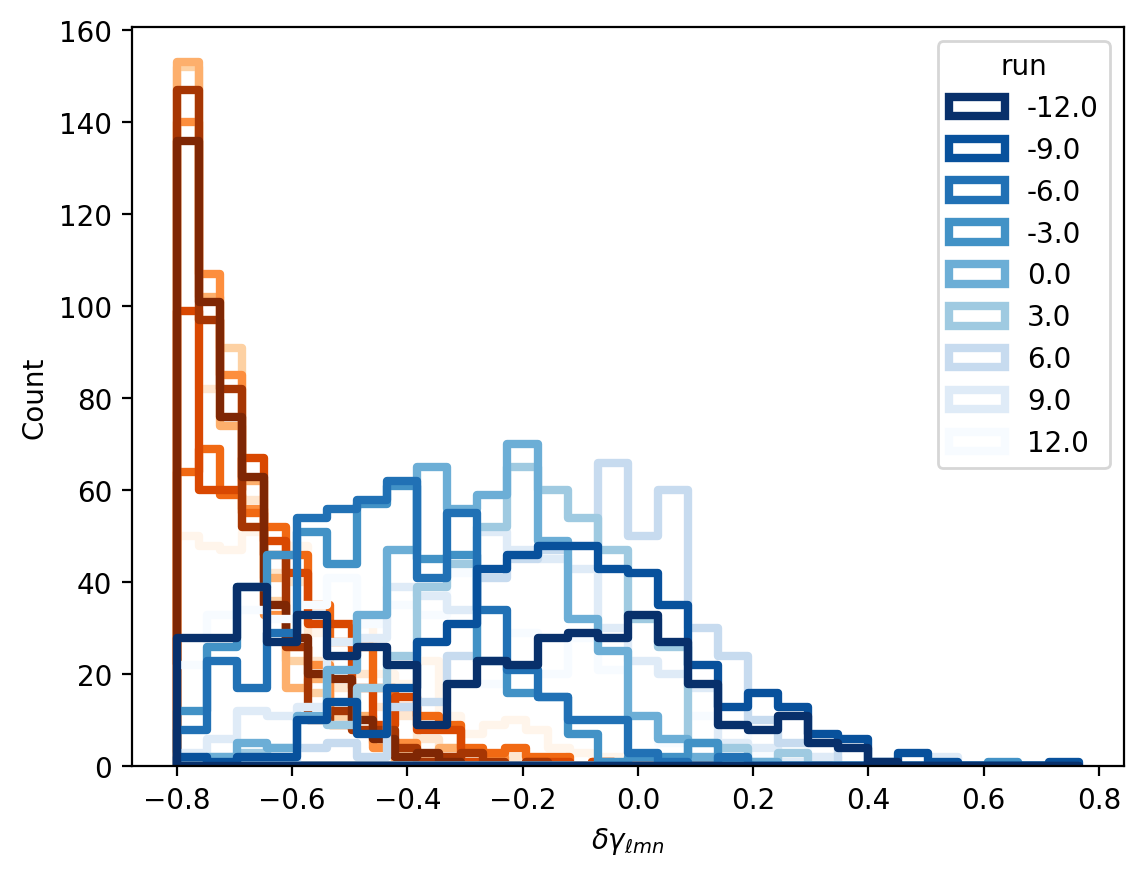

In [ ]:
sns.histplot(dfo, x='dg_221', element='step', alpha=0, palette='Oranges_r', hue='run', lw=3, bins=30)
sns.histplot(dff, x='dg_210', element='step', alpha=0, palette='Blues_r', hue='run', lw=3, bins=30)

plt.xlabel('$\delta \gamma_{\ell m n}$')

In [ ]:
f220, t220 = rd.qnms.get_ftau(mf_h, 0.67721823, l=2, m=2, n=0)
f210, t210 = rd.qnms.get_ftau(mf_h, 0.67721823, l=2, m=1, n=0)
f221, t221 = rd.qnms.get_ftau(mf_h, 0.67721823, l=2, m=2, n=1)

In [ ]:
np.log(f220/f210)

np.float64(0.14923766598741342)

In [ ]:
f210, f210 * np.exp(0.5), f220*1.2

(np.float64(45.298166551928574),
 np.float64(74.68405071788172),
 np.float64(63.10662656958598))

### DS heavy

In [ ]:
coll1 = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/ds/1DS_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')
coll2 = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/ds/2DS_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')
coll3 = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/ds/3DS_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
m_h = coll1[0].config['model']['m_min'] * 2
m_h

321.23764612

In [ ]:
fs = {}
gs = {}

for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(m_h, 0.67721823, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

In [ ]:
coll1.reindex_by_t0(reference_time=1126259462.423, reference_mass=m_h, decimals=0)
coll2.reindex_by_t0(reference_time=1126259462.423, reference_mass=m_h, decimals=0)
coll3.reindex_by_t0(reference_time=1126259462.423, reference_mass=m_h, decimals=0)

In [ ]:
df1 = coll1.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
df2 = coll2.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
df3 = coll3.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

(0.0, 200.0)

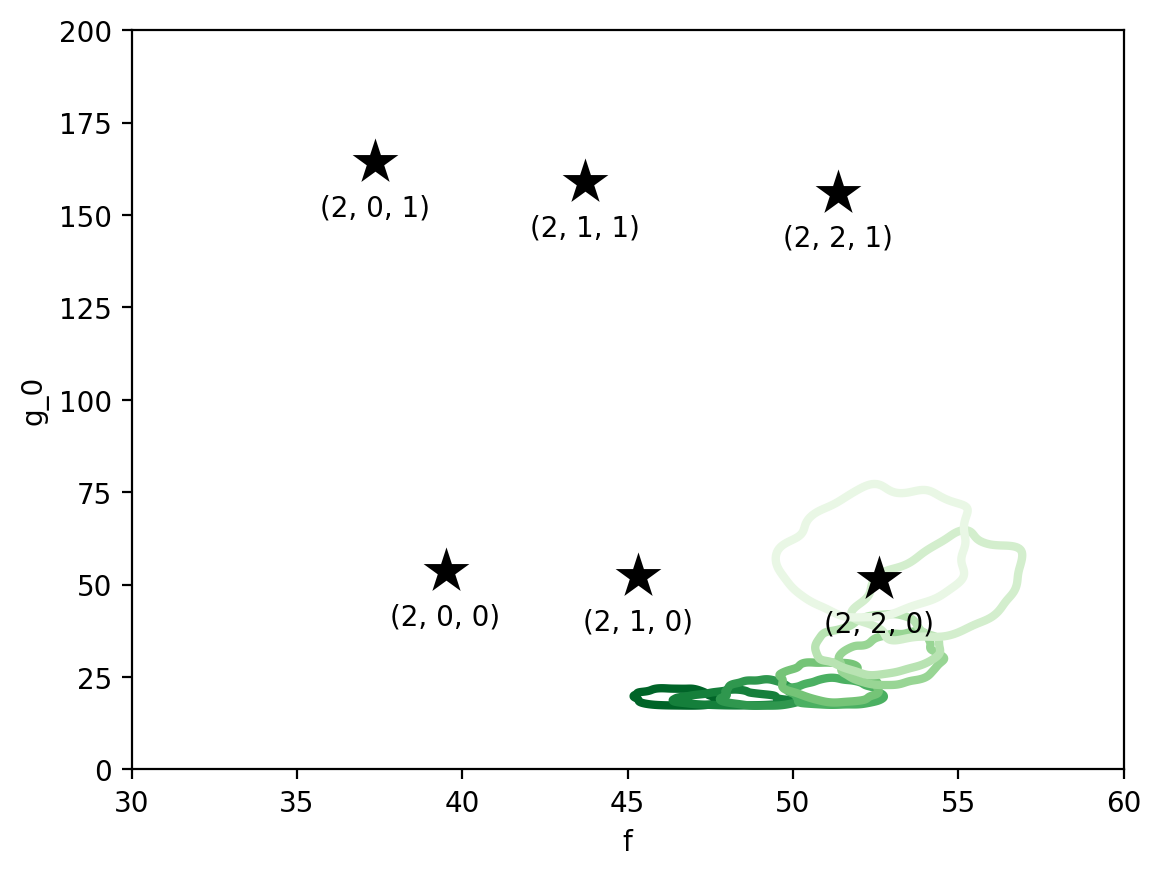

In [ ]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=mode, x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df1['run'].unique()):
    sns.kdeplot(df1[df1['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens_r', n_colors=len(df1['run'].unique()))[i],
                linewidths=3, levels=[0.1])

plt.xlabel('f')
plt.xlim(30, 60)
plt.ylim(0, 200)

(0.0, 200.0)

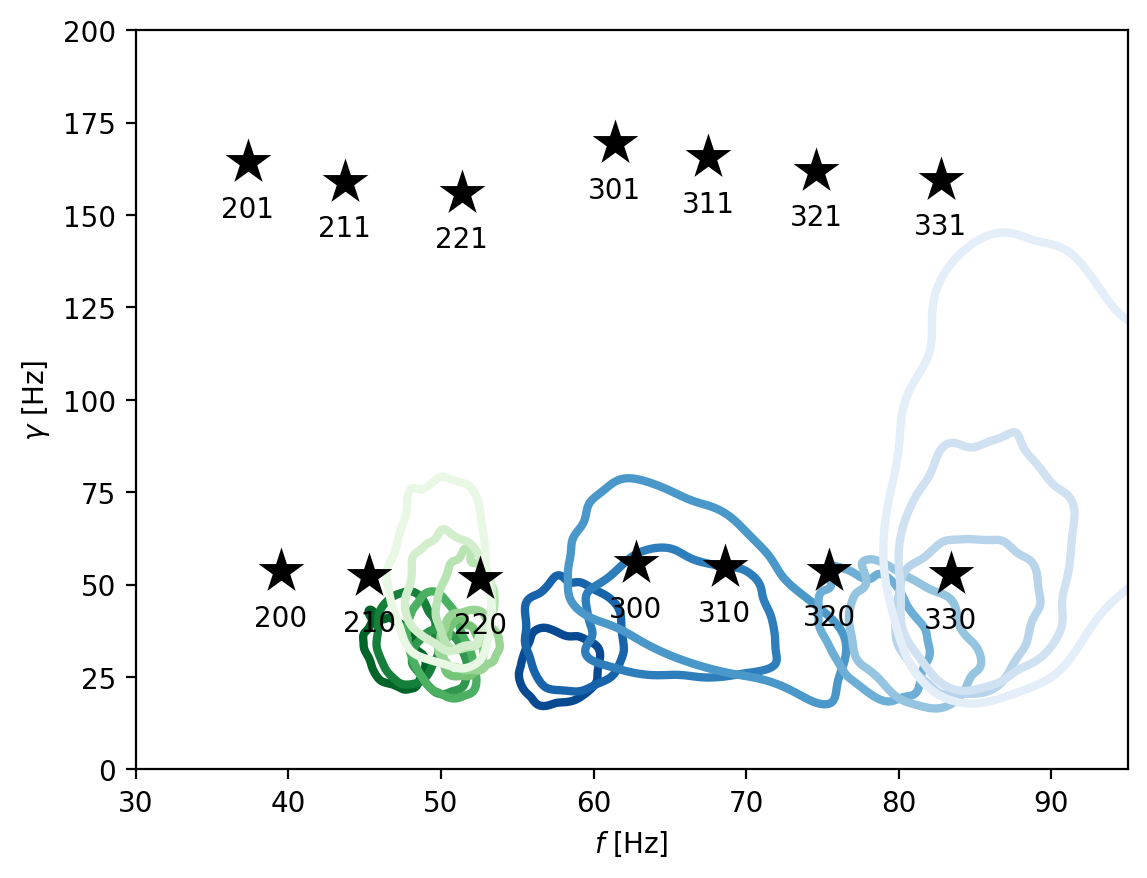

In [ ]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=f'{mode[0]}{mode[1]}{mode[2]}', x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df2['run'].unique()):
    sns.kdeplot(df2[df2['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens_r', n_colors=len(df2['run'].unique()))[i],
                linewidths=3, levels=[0.1])
    sns.kdeplot(df2[df2['run'] == run], x='f_1', y='g_1', 
                color=sns.color_palette('Blues_r', n_colors=len(df2['run'].unique()))[i],
                linewidths=3, levels=[0.1])

plt.xlabel('$f$ [Hz]')
plt.ylabel('$\gamma$ [Hz]')
plt.xlim(30, 95)
plt.ylim(0, 200)

array([[<Axes: ylabel='a\n1'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='f\n0'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='a\n0', ylabel='f\n1'>, <Axes: xlabel='a\n1'>,
        <Axes: xlabel='f\n0'>]], dtype=object)

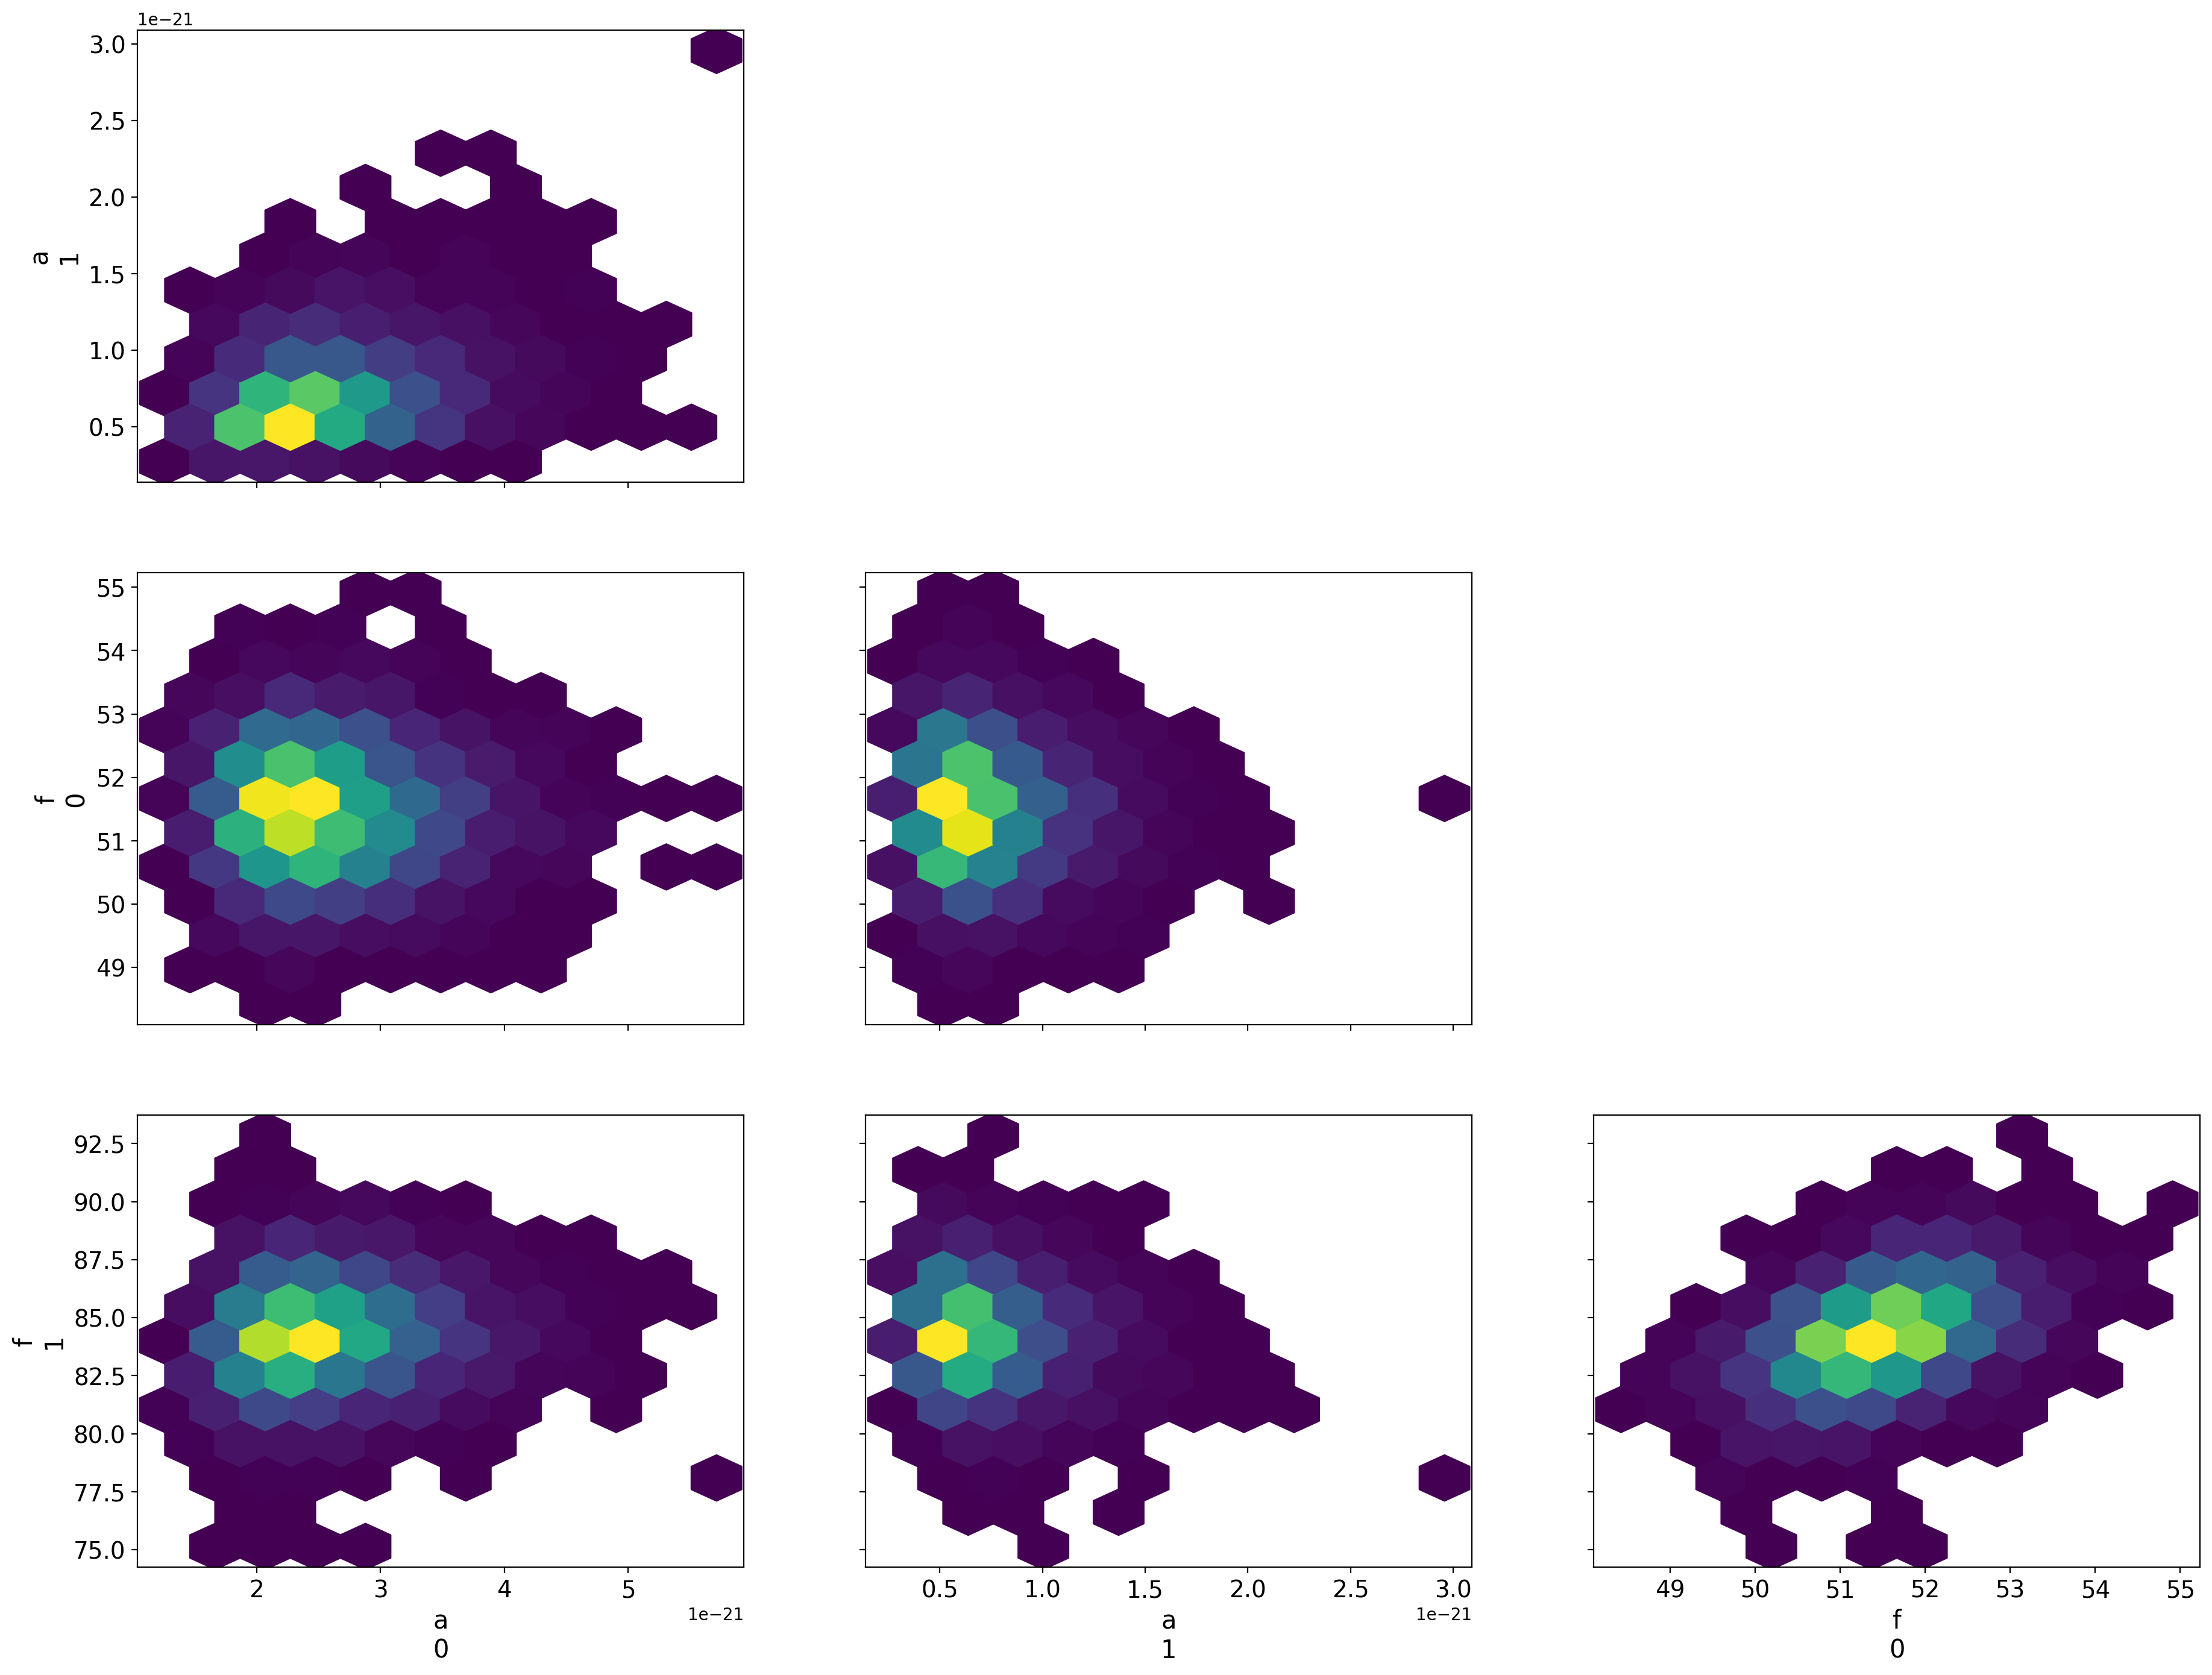

In [ ]:
az.plot_pair(coll2.idx[6], var_names=['a', 'f'], kind='hexbin')

(0.0, 200.0)

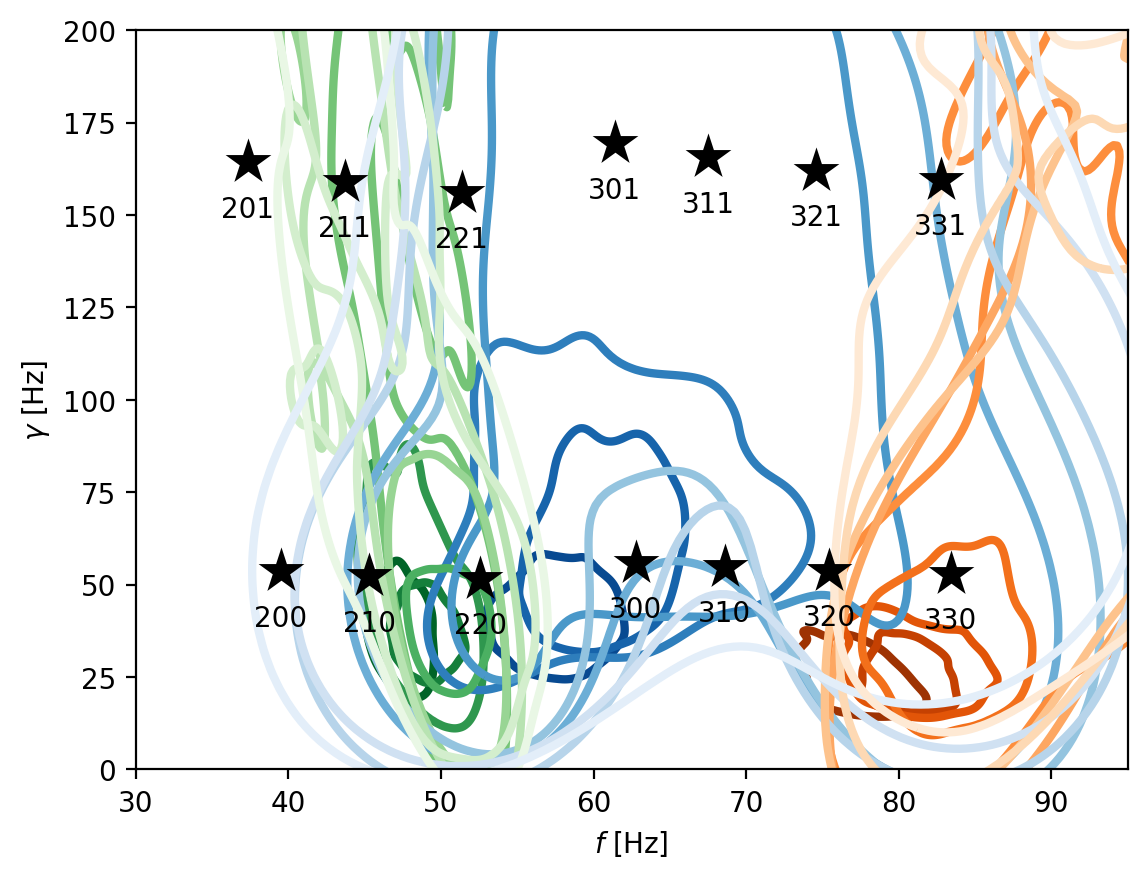

In [ ]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=f'{mode[0]}{mode[1]}{mode[2]}', x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df3['run'].unique()):
    sns.kdeplot(df3[df3['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens_r', n_colors=len(df3['run'].unique()))[i],
                linewidths=3, levels=[0.1])
    sns.kdeplot(df3[df3['run'] == run], x='f_1', y='g_1', 
                color=sns.color_palette('Blues_r', n_colors=len(df3['run'].unique()))[i],
                linewidths=3, levels=[0.1])
    sns.kdeplot(df3[df3['run'] == run], x='f_2', y='g_2', 
                color=sns.color_palette('Oranges_r', n_colors=len(df3['run'].unique()))[i],
                linewidths=3, levels=[0.1])

plt.xlabel('$f$ [Hz]')
plt.ylabel('$\gamma$ [Hz]')
plt.xlim(30, 95)
plt.ylim(0, 200)

array([[<Axes: ylabel='a\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='a\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='g\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='g\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='a\n0', ylabel='g\n2'>, <Axes: xlabel='a\n1'>,
        <Axes: xlabel='a\n2'>, <Axes: xlabel='g\n0'>,
        <Axes: xlabel='g\n1'>]], dtype=object)

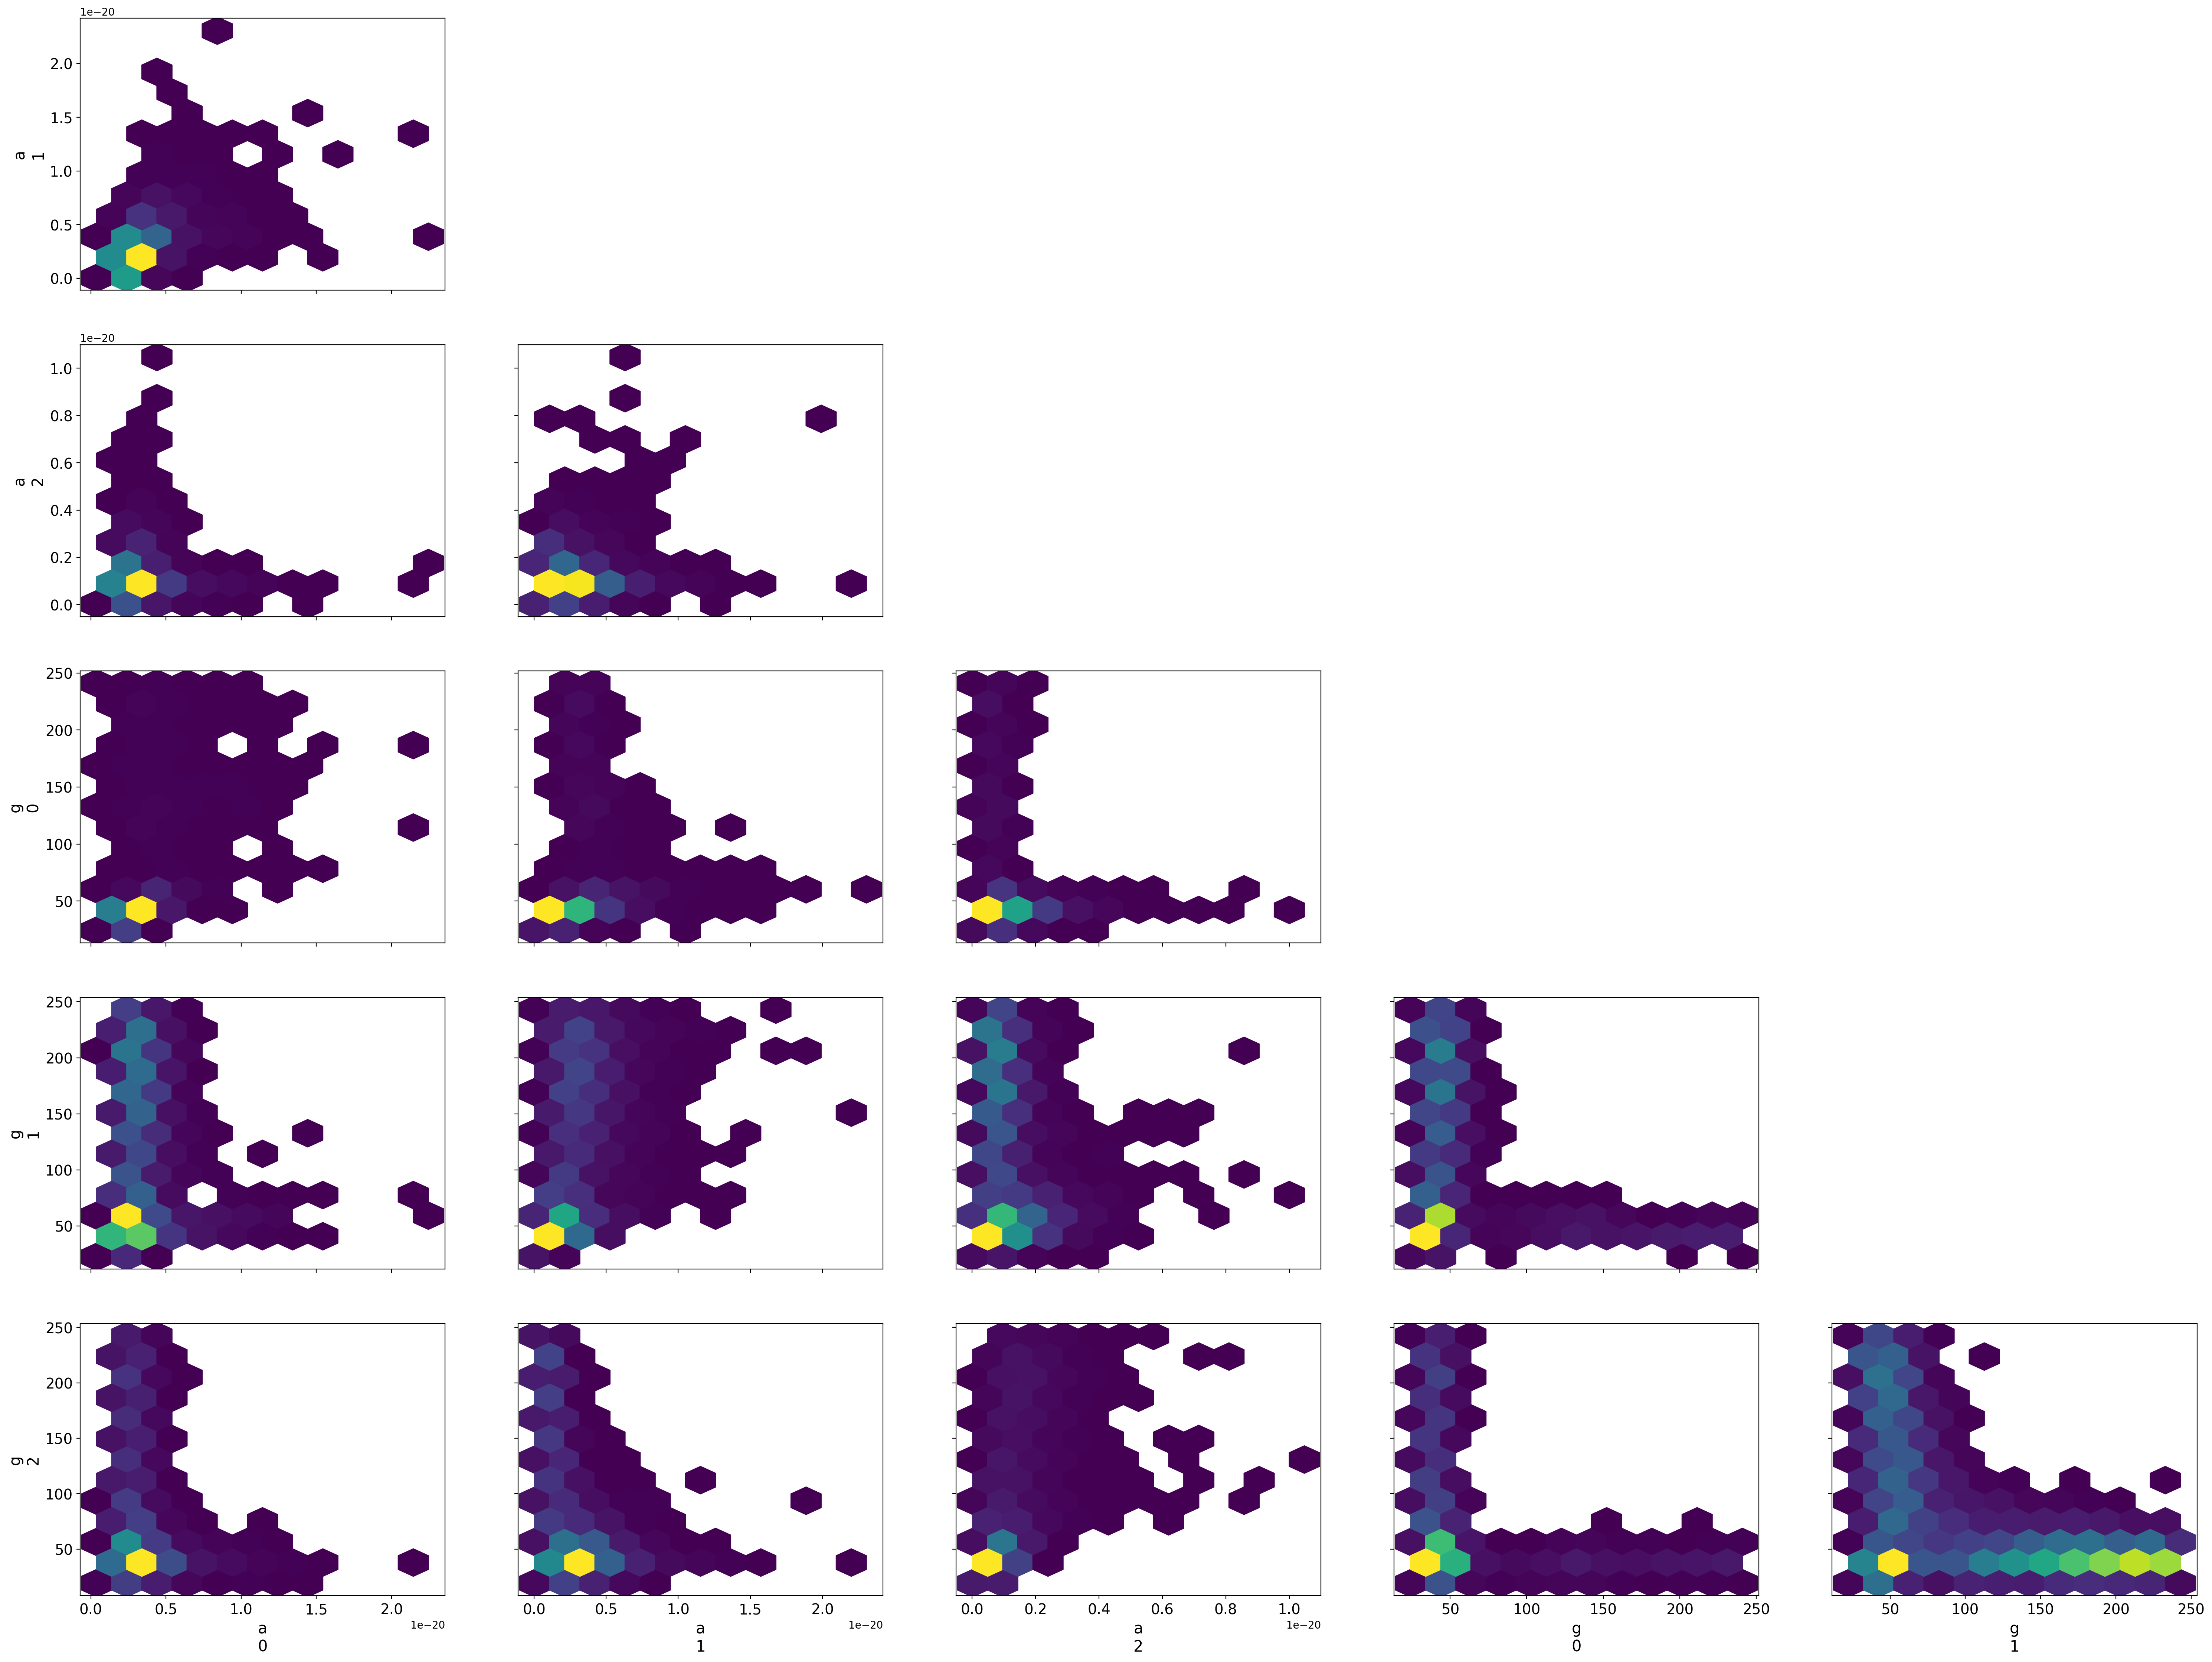

In [ ]:
az.plot_pair(coll3.idx[3], var_names=['a', 'g'], kind='hexbin')

In [ ]:
# import h5py

# t0 = 1126259462.423
# ra = 1.952318922
# dec = -1.26967171703
# psi = 0.824043851821

# ## temporary rd.Fit object
# temp_fit = rd.Fit()

# ## creating empty data arrays with the appropriately delayed and discretized timestamps
# temp_fit.fake_data(duration=4,
#                 prng=1234,
#                 ifos=["H1", "L1"],
#                 f_min=10,
#                 f_samp=4096,
#                 t0=t0)

# ## setting GW150914 target
# temp_fit.set_target(t0=t0, 
#                     ra=ra, 
#                     dec=dec, 
#                     psi=psi, 
#                     duration=0.5)

# fit = temp_fit.copy()

# ############ temp_fit ###########

# ## constructing the injection from an LVCNR .h5 file
# nr_path = '/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1156/SXS_BBH_1156_Res3.h5'
# # get true remnant values
# mtot = 330
# with h5py.File(nr_path, 'r') as f:
#     Mflower = f.attrs['f_lower_at_1MSUN']
#     mf_true = f['remnant-mass-vs-time']['Y'][-1]
#     cfx = f['remnant-spinx-vs-time']['Y'][-1]
#     cfy = f['remnant-spiny-vs-time']['Y'][-1]
#     cfs = f['remnant-spinz-vs-time']['Y'][-1]
#     cf_true = np.linalg.norm([cfx, cfy, cfs])
#     q_true = f.attrs['mass2']/f.attrs['mass1']
# mf_true *= mtot
# f_start = Mflower/mtot
# print(f'Starting frequency: {f_start} Hz')
# TM = mf_true*rd.qnms.T_MSUN
# print(mf_true, cf_true)

# # injection params
# dL = 440
# wf_kws = dict(
#     model = 'NR_hdf5',
#     mtot = mtot,
#     q=q_true,
#     # define extrinsic source parameters
#     ra = ra,
#     dec = dec,
#     psi = psi,
#     inclination = np.pi/3 + 1e-16, ## avoid numerical issues from being exactly face-on
#     dist = dL,
#     # phi_ref = 2.41342424662,
#     geocent_time = t0,
#     f_low = f_start,
#     f_ref = 20,
#     window=True,
#     nr_path = nr_path)

# # inject signal into rd.Fit object
# temp_fit.inject(**wf_kws, no_noise=True)

# # temp_fit.condition_data(f_min=10, ds=1, trim=0)
# # temp_fit.load_acfs({'H1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_H1_psd_patched4kHz_1e-40.hdf5', 
# #                     'L1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_L1_psd_patched4kHz_1e-40.hdf5'},
# #                     from_psd=True)

# # wd = temp_fit.whiten(temp_fit.analysis_data)
# # cumsnr = {i: np.sqrt(np.cumsum(d*d)) for i, d in wd.items()}
# # ppSNR = float(np.linalg.norm([cs.iloc[-1] for cs in cumsnr.values()]))
# # snr_scale = ppSNR / float(args.snr)
# # print(ppSNR)
# # print(snr_scale)

In [ ]:
# old = temp_fit.analysis_data.copy()

In [ ]:
# for i, d in temp_fit.analysis_data.items():
#     l, = plt.plot(d, lw=3, alpha=0.3)
#     plt.plot(old[i], ls='--', color=l.get_color())

In [ ]:
# (old[i] == temp_fit.analysis_data[i]).all()

### DS light

In [55]:
coll1 = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/ds/1DS_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined/engine/*/result.nc')
coll2 = rd.ResultCollection.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/ds/2DS_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [56]:
m_l = coll1[0].config['model']['m_min'] * 2
m_l

70.0882137

In [58]:
mf_true = 70.0882137
cf_true = 0.67721823

In [59]:
fs = {}
gs = {}

for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

In [60]:
coll1.reindex_by_t0(reference_time=1126259462.423, reference_mass=m_l, decimals=0)
coll2.reindex_by_t0(reference_time=1126259462.423, reference_mass=m_l, decimals=0)

In [61]:
df1 = coll1.get_parameter_dataframe(ndraw=500, progress=True, prng=13)
df2 = coll2.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

(150.0, 400.0)

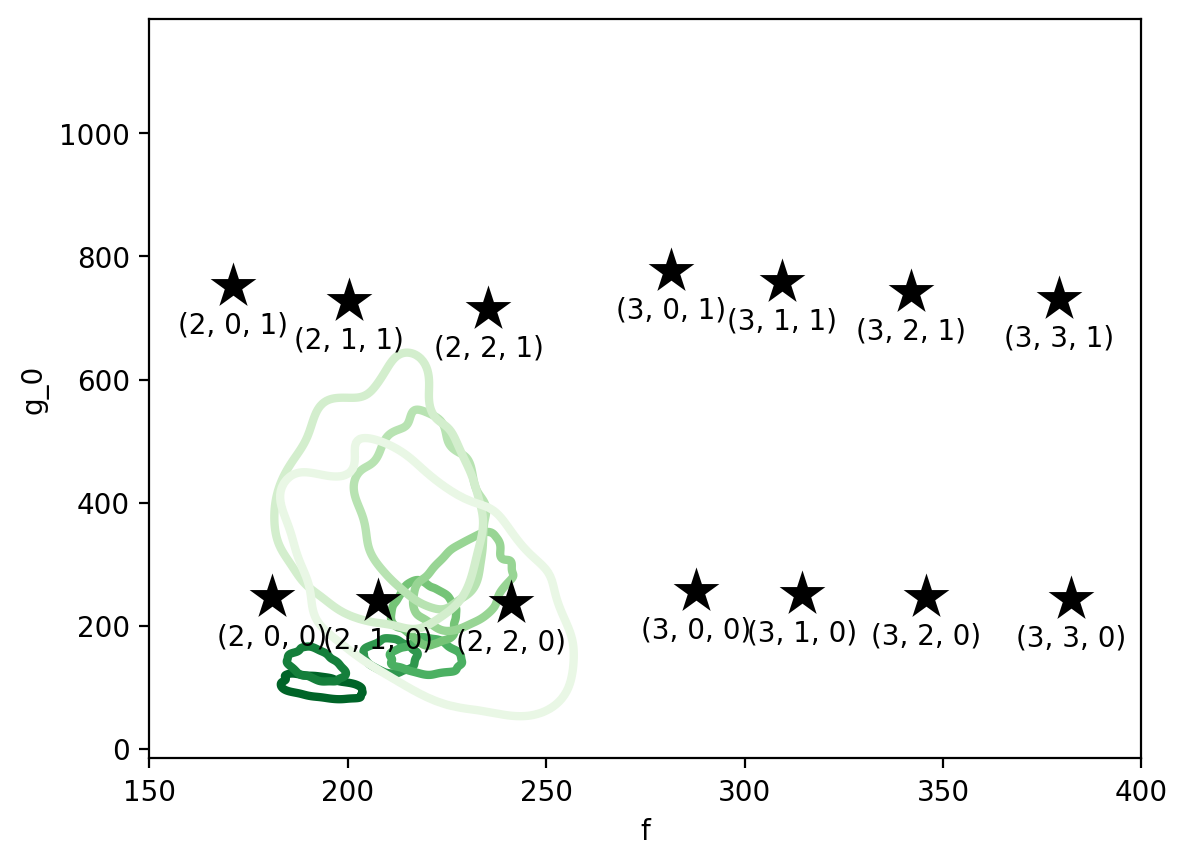

In [ ]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=mode, x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df1['run'].unique()):
    sns.kdeplot(df1[df1['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens_r', n_colors=len(df1['run'].unique()))[i],
                linewidths=3, levels=[0.1])

plt.xlabel('f')
plt.xlim(150, 400)
# plt.ylim(0, 200)

(150.0, 500.0)

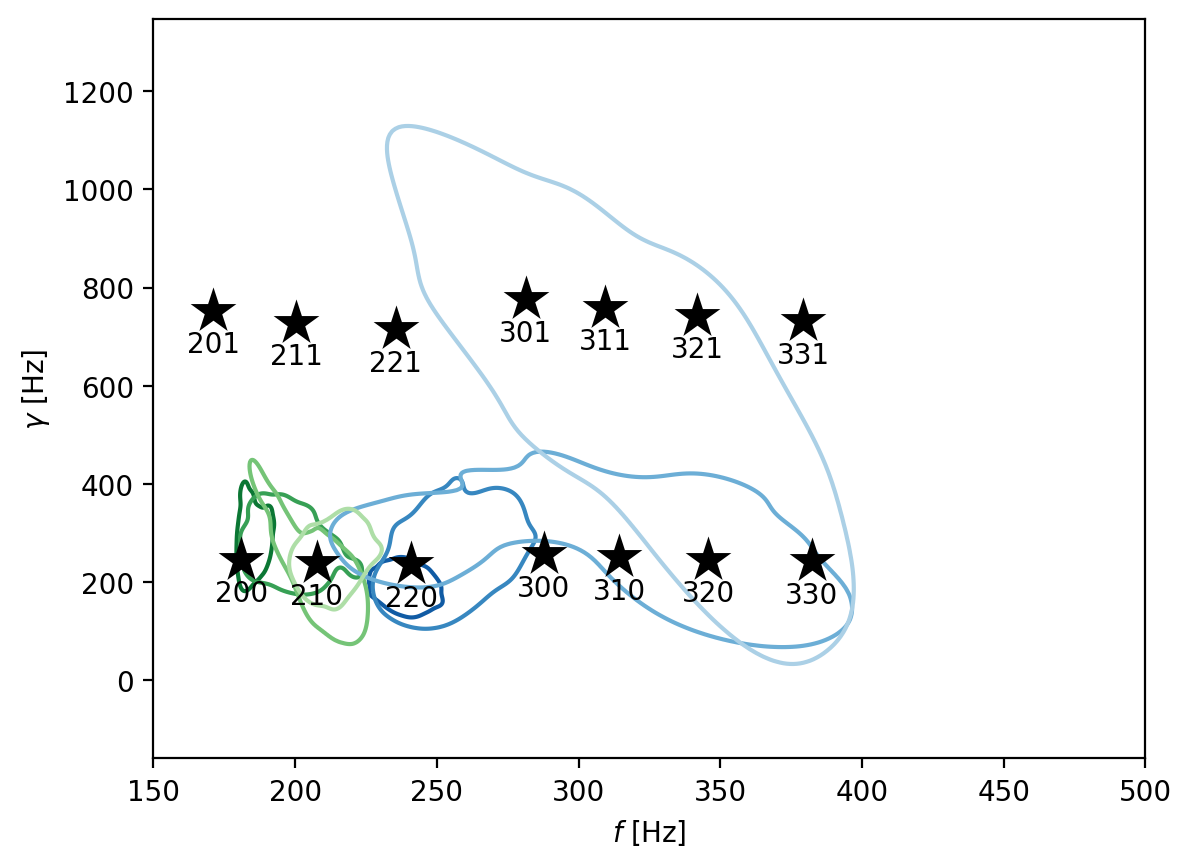

In [95]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=f'{mode[0]}{mode[1]}{mode[2]}', x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df2[df2['run'] < 0]['run'].unique()):
    lw = 3 if run == 0 else 1.5
    sns.kdeplot(df2[df2['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens_r', n_colors=len(df2['run'].unique())-4)[i],
                linewidths=lw, levels=[0.1])
    sns.kdeplot(df2[df2['run'] == run], x='f_1', y='g_1', 
                color=sns.color_palette('Blues_r', n_colors=len(df2['run'].unique())-4)[i],
                linewidths=lw, levels=[0.1])

plt.xlabel('$f$ [Hz]')
plt.ylabel('$\gamma$ [Hz]')
plt.xlim(150, 500)
# plt.ylim(0, 200)

(150.0, 500.0)

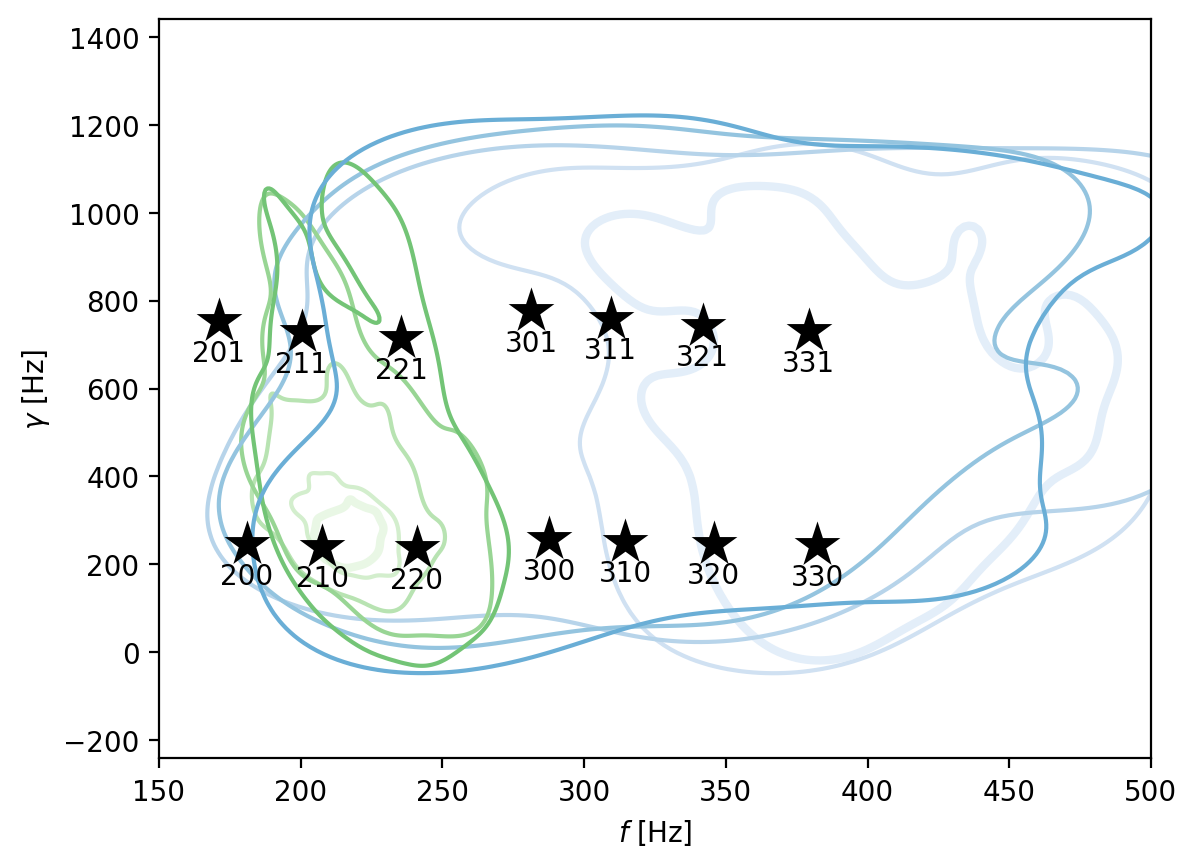

In [69]:
# sns.scatterplot(x=fs.values(), y=gs.values(), hue=fs.keys(), palette='husl', marker='*', s=300, lw=0)

for mode in fs.keys():
    plt.scatter(x=fs[mode], y=gs[mode], color='k', marker='*', s=300, lw=0, zorder=19)
    plt.text(s=f'{mode[0]}{mode[1]}{mode[2]}', x=fs[mode], y=gs[mode]-(0.075*(max(gs.values()) - min(gs.values()))), ha='center', va='top')

for i, run in enumerate(df2[df2['run'] >= 0]['run'].unique()):
    lw = 3 if run == 0 else 1.5
    sns.kdeplot(df2[df2['run'] == run], x='f_0', y='g_0', 
                color=sns.color_palette('Greens', n_colors=len(df2['run'].unique()))[i],
                linewidths=lw, levels=[0.1])
    sns.kdeplot(df2[df2['run'] == run], x='f_1', y='g_1', 
                color=sns.color_palette('Blues', n_colors=len(df2['run'].unique()))[i],
                linewidths=lw, levels=[0.1])

plt.xlabel('$f$ [Hz]')
plt.ylabel('$\gamma$ [Hz]')
plt.xlim(150, 500)
# plt.ylim(0, 200)

array([[<Axes: ylabel='a\n1'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='f\n0'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='a\n0', ylabel='f\n1'>, <Axes: xlabel='a\n1'>,
        <Axes: xlabel='f\n0'>]], dtype=object)

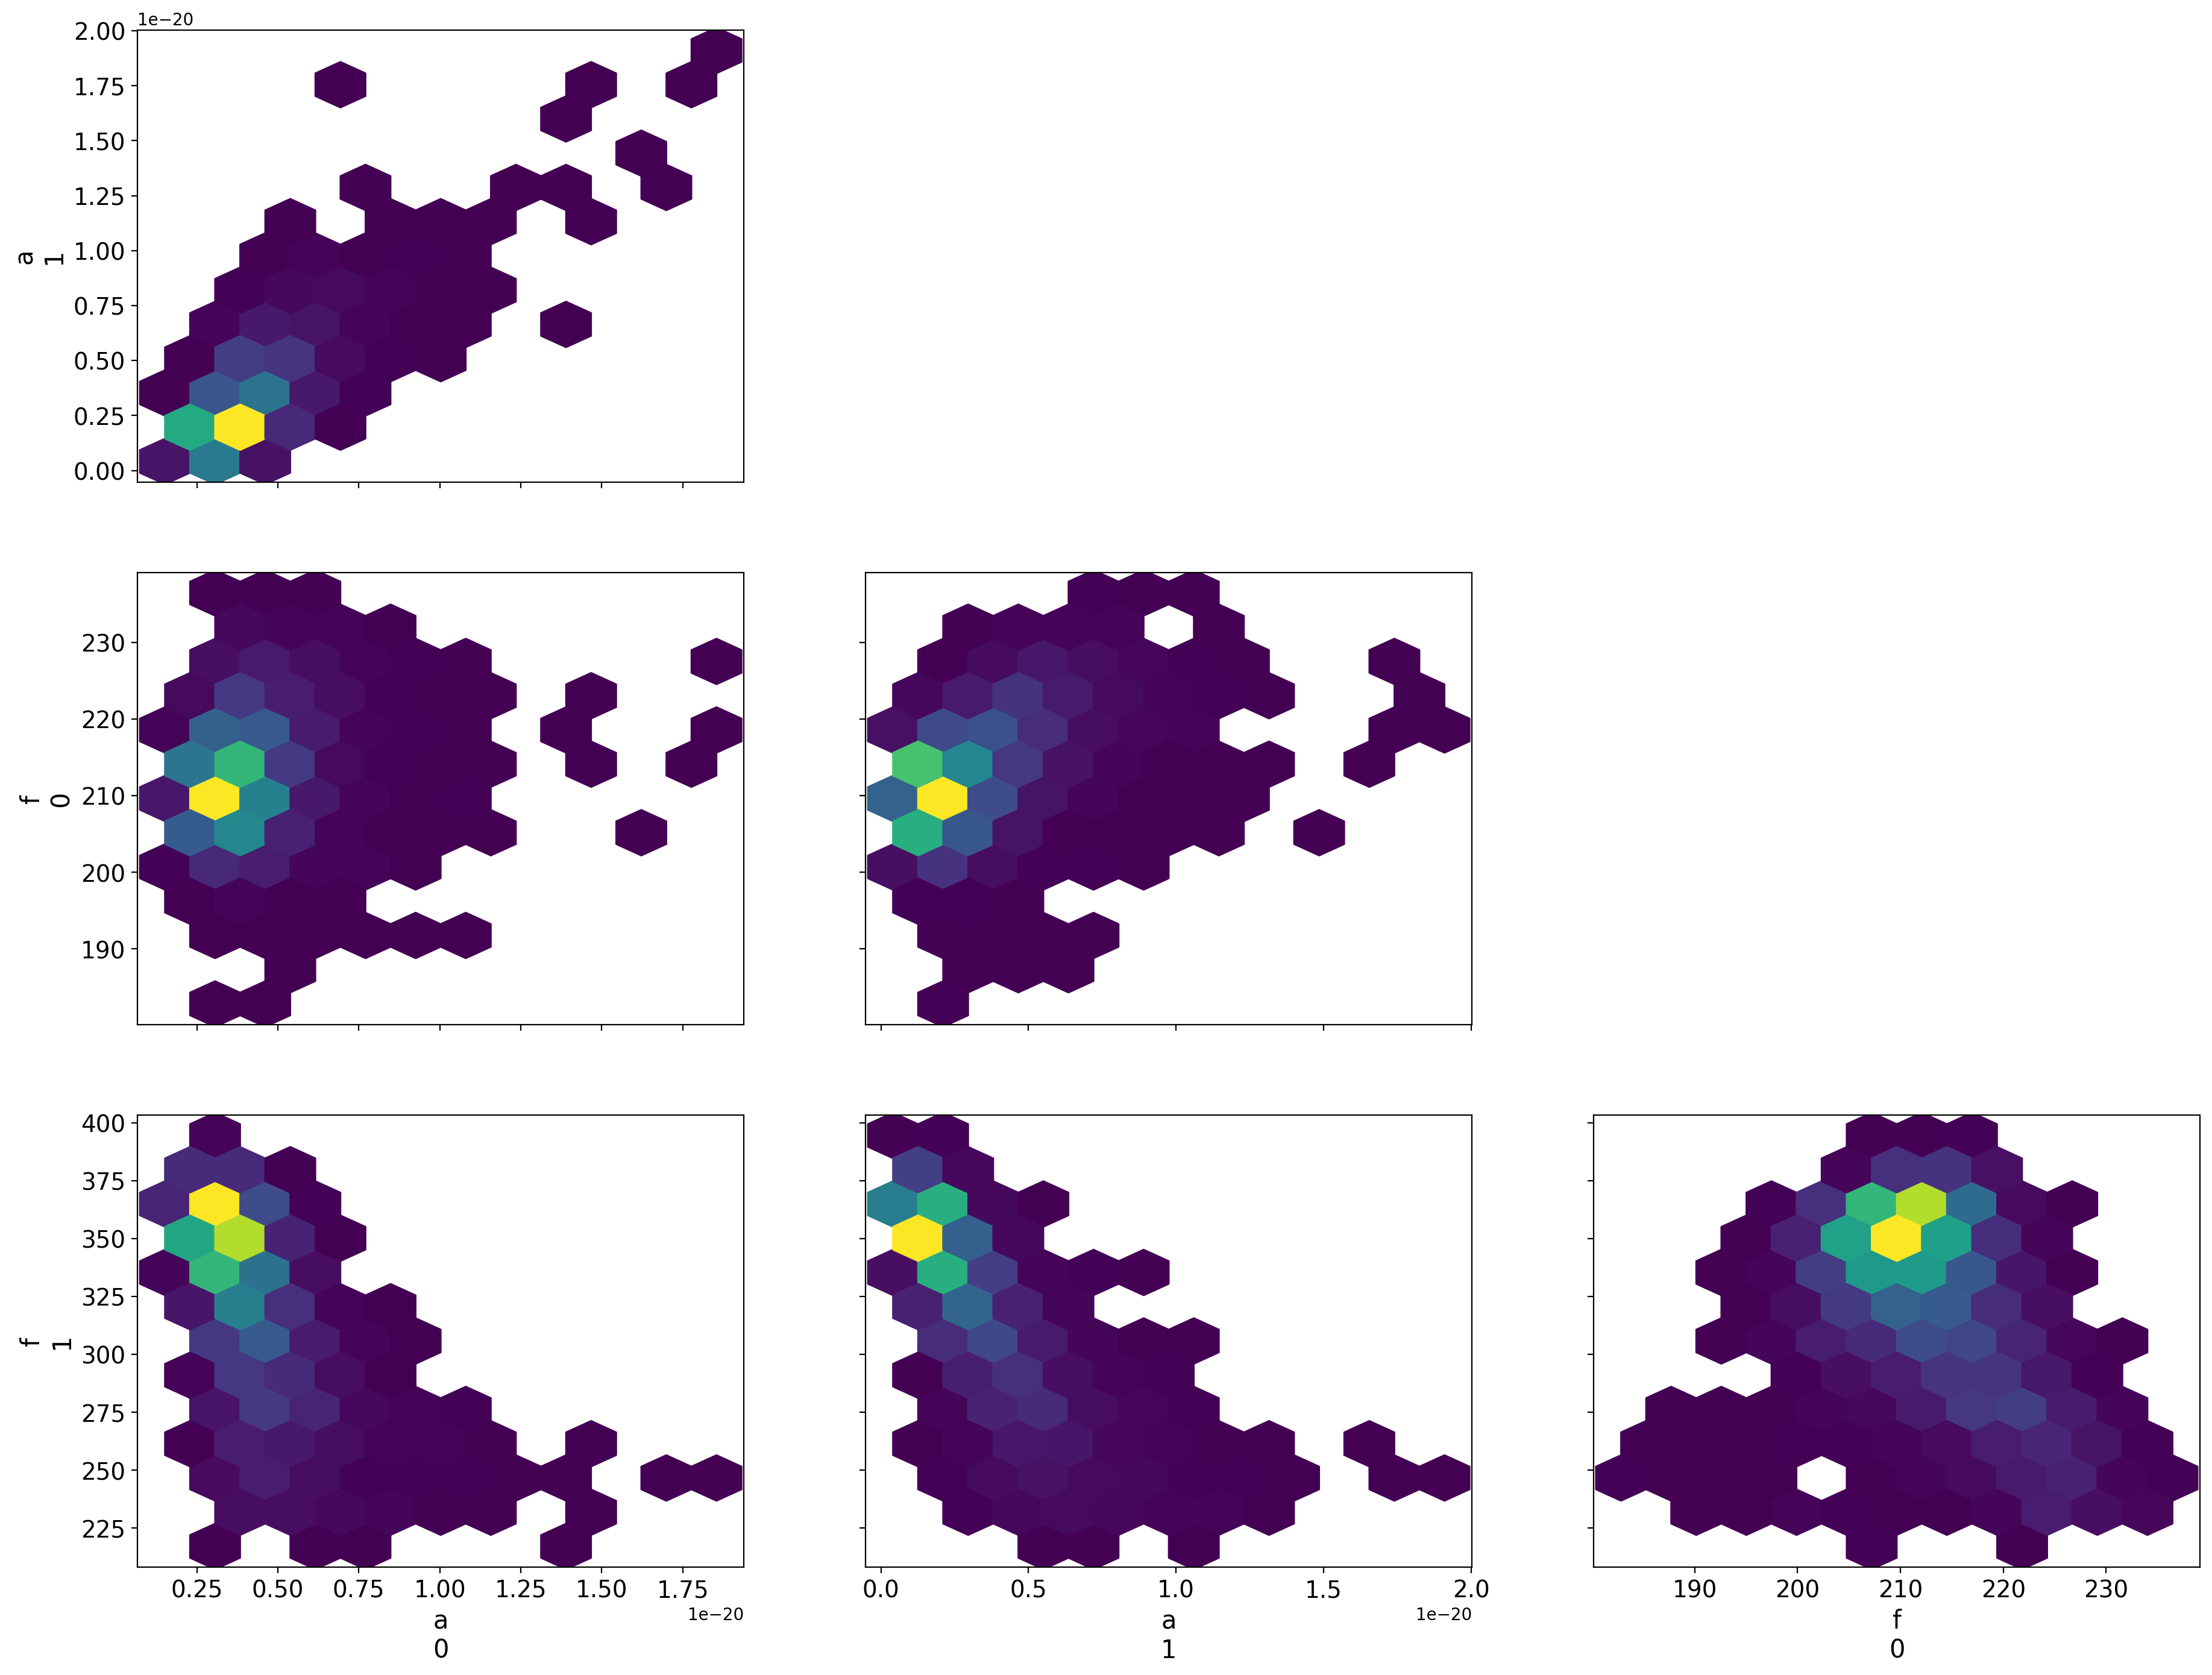

In [98]:
az.plot_pair(coll2.idx[-3], var_names=['a', 'f'], kind='hexbin')

### 220+330

In [3]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [4]:
run = 'SXS_BBH_1156/mtot330/linesub/220+330_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_Mcut'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [5]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [18]:
coll[0].config

{'model': {'modes': [(1, -2, 2, 2, 0), (1, -2, 3, 3, 0)],
  'a_scale_max': 1e-19,
  'm_min': 160.61882306,
  'm_max': 550.0,
  'marginalized': True},
 'target': {'t0': 1126259462.4040132,
  'ra': 1.952318922,
  'dec': -1.26967171703,
  'psi': 0.824043851821,
  'duration': 0.5,
  'reference_ifo': None,
  'antenna_patterns': None,
  'target': None,
  'force': False},
 'data': {'path': {'H1': '/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/linesub/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_H1.hdf5',
   'L1': '/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/linesub/SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_L1.hdf5'},
  'ifos': None,
  'channel': None,
  'frametype': None,
  'slide': None},
 'condition': {'preserve_acfs': False,
  'silent': False,
  'f_min': 10.0,
  'ds': 1.0,
  'trim': 0.0},
 'acf': {'path': {'H1': '/mnt/home/nkhusid/spec_inj/data/bilby-NRSur7dq4_high_f_cal_H1_psd_patched4kHz_1e-40.hdf5',
   'L1': '/mnt/home/nkhusid/spec_inj/data/b

In [21]:
t0 = 1126259462.423

In [25]:
ifo = 'H1'
psd = pd.read_hdf(str(dirs.datdir / f'bilby-NRSur7dq4_high_f_cal_{ifo}_psd_patched4kHz_1e-40.hdf5'), key=ifo)

In [ ]:
colls[20][0].constant_data.time[f]

<xarray.DataArray 'time' (ifo: 2, time_index: 2048)> Size: 33kB
[4096 values with dtype=float64]
Coordinates:
  * ifo         (ifo) <U2 16B 'H1' 'L1'
  * time_index  (time_index) int64 16kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047

In [34]:
len(coll[0].constant_data.time[0,:].values), len(coll[0].analysis_data[ifo]), len(fs)

(2048, 2048, 1025)

In [36]:
1 / (coll[0].constant_data.time[0,:].values[1] - coll[0].constant_data.time[0,:].values[0])

np.float64(4096.0)

In [44]:
pd.read_hdf(coll[0].config['data']['path']['H1'], key='H1')

1.126259e+09    1.469827e-206
1.126259e+09    1.487821e-206
1.126259e+09    1.411366e-206
1.126259e+09    1.235149e-206
1.126259e+09    9.597442e-207
                    ...      
1.126259e+09    3.708949e-204
1.126259e+09    8.191712e-207
1.126259e+09   -3.330986e-204
1.126259e+09   -5.832351e-204
1.126259e+09   -7.194745e-204
Name: H1, Length: 16384, dtype: float64

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

results:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_2958251/1064375426.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


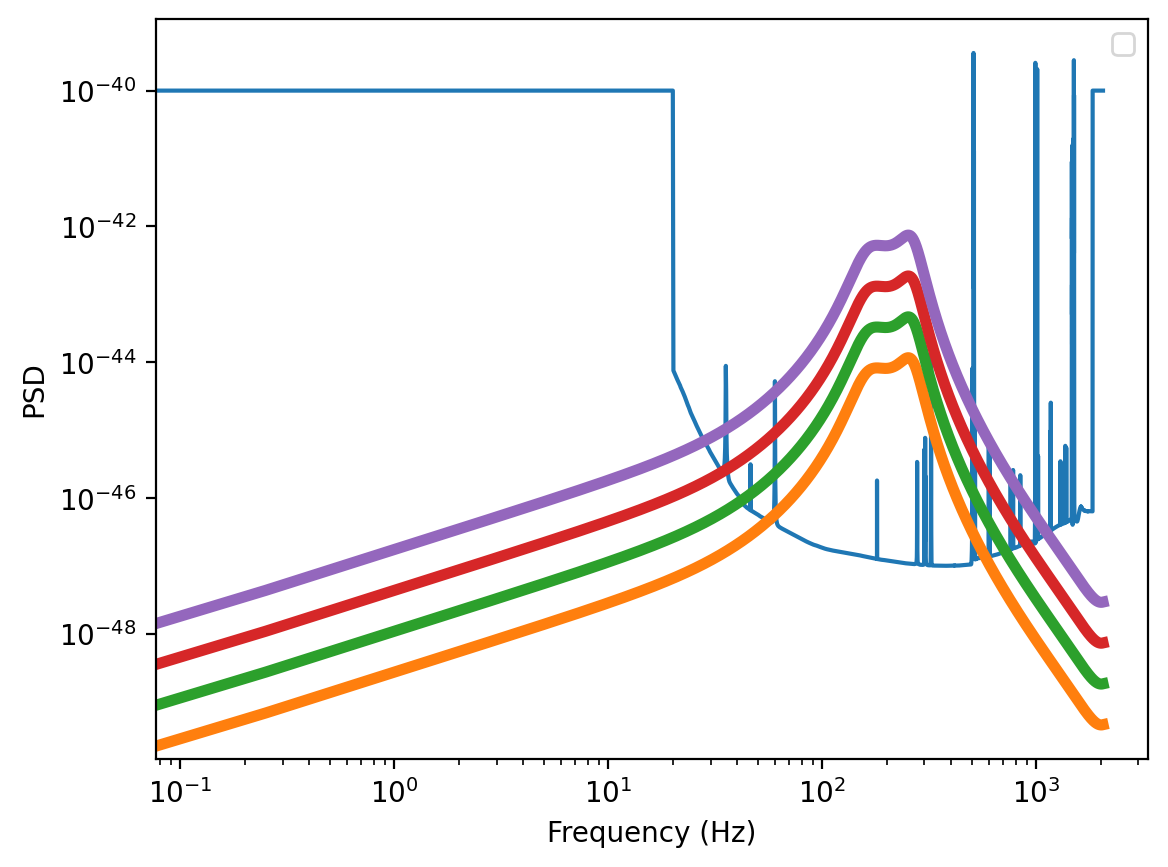

In [47]:
snrs = [20, 40, 80, 160]
colls = {snr: rd.ResultCollection.from_netcdf(str(dirs.resdir / 'DS' / '220' / f'220+221_DS_GW250114Kerr_fmin10Hz_ppSNR{snr}_dfpre-0.5_dtaupre0' / 'engine' / '*' / 'result.nc')) for snr in snrs}
for coll in colls.values():
    coll.reindex_by_t0(reference_mass=coll[0].config['model']['m_min'] * 2, reference_time=t0, decimals=0)
# dfs = {snr: coll.get_parameter_dataframe(ndraw=500, prng=13, progress=True) for snr, coll in colls.items()}
ifo = 'H1'
plt.loglog(psd)
dt = 1 / 4096
for snr, coll in colls.items():
    h = pd.read_hdf(coll[0].config['data']['path']['H1'], key='H1')
    h_freq = np.fft.rfft(h.values) * dt
    fs = np.fft.rfftfreq(len(h.index.values), d=dt)
    l, = plt.loglog(fs, 4*fs*np.abs(h_freq)**2, lw=4)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()

In [6]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [179]:
mf_true = 321.23764612
cf_true = 0.67721823

(250.0, 550.0)

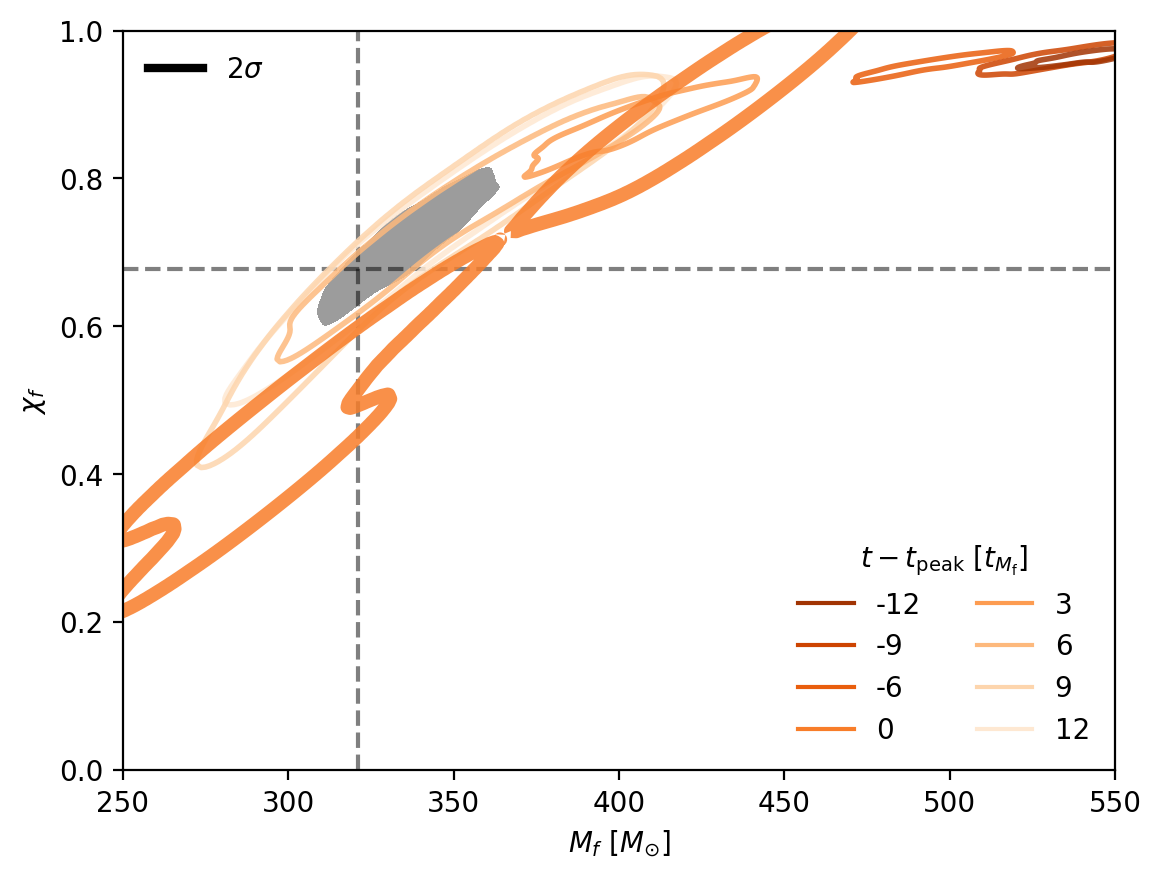

In [180]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[(df_full['f_330'] > 60) & (df_full['chi'] > 0)], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
ax.set_xlim(250, 550)

In [184]:
df_full[df_full['run'] == 0] = df_full[df_full['run'] == 0][df_full[df_full['run'] == 0]['chi'] > 0.6]
df_full[df_full['run'] > 6] = df_full[df_full['run'] > 6][df_full[df_full['run'] > 6]['chi'] > 0.35]

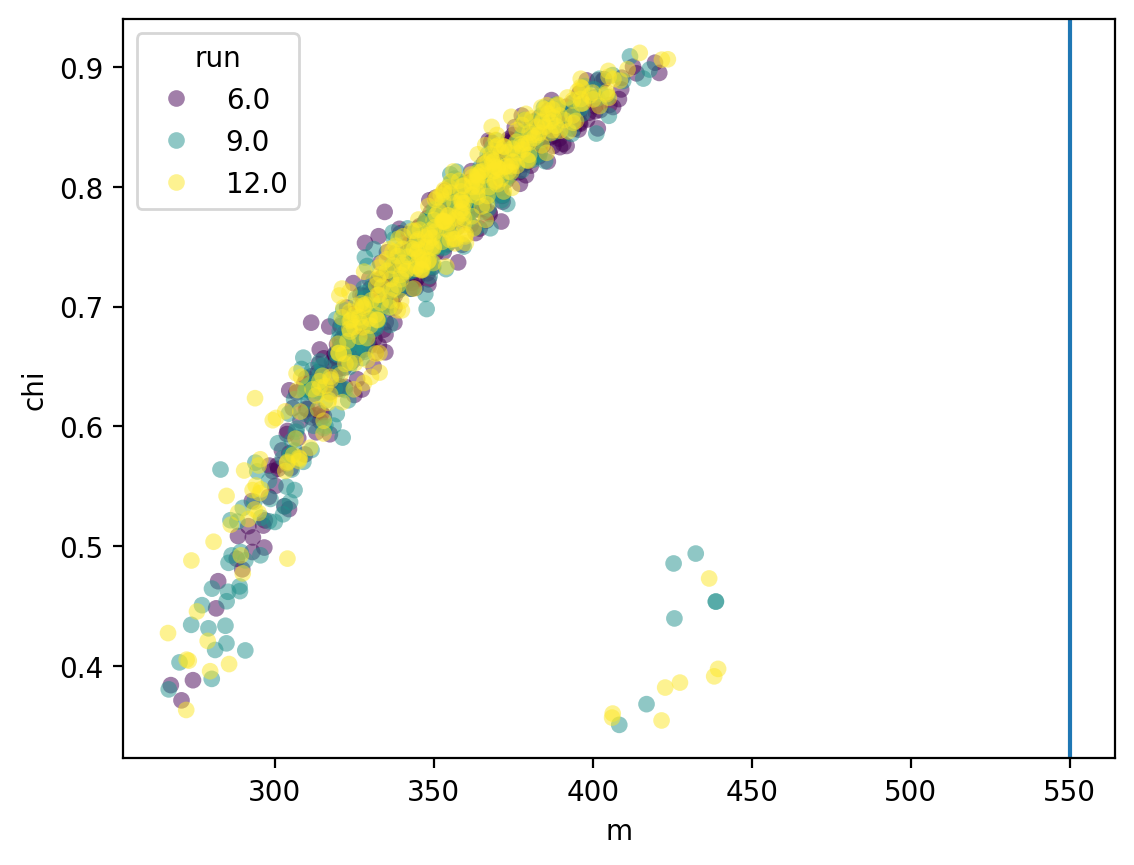

In [185]:
sns.scatterplot(df_full[df_full['run'] >= 6], x='m', y='chi', hue='run', palette='viridis', lw=0, alpha=0.5)
plt.axvline(550)

[9.94321229e-22 2.84758450e-22]
{'220+330': 6}
2


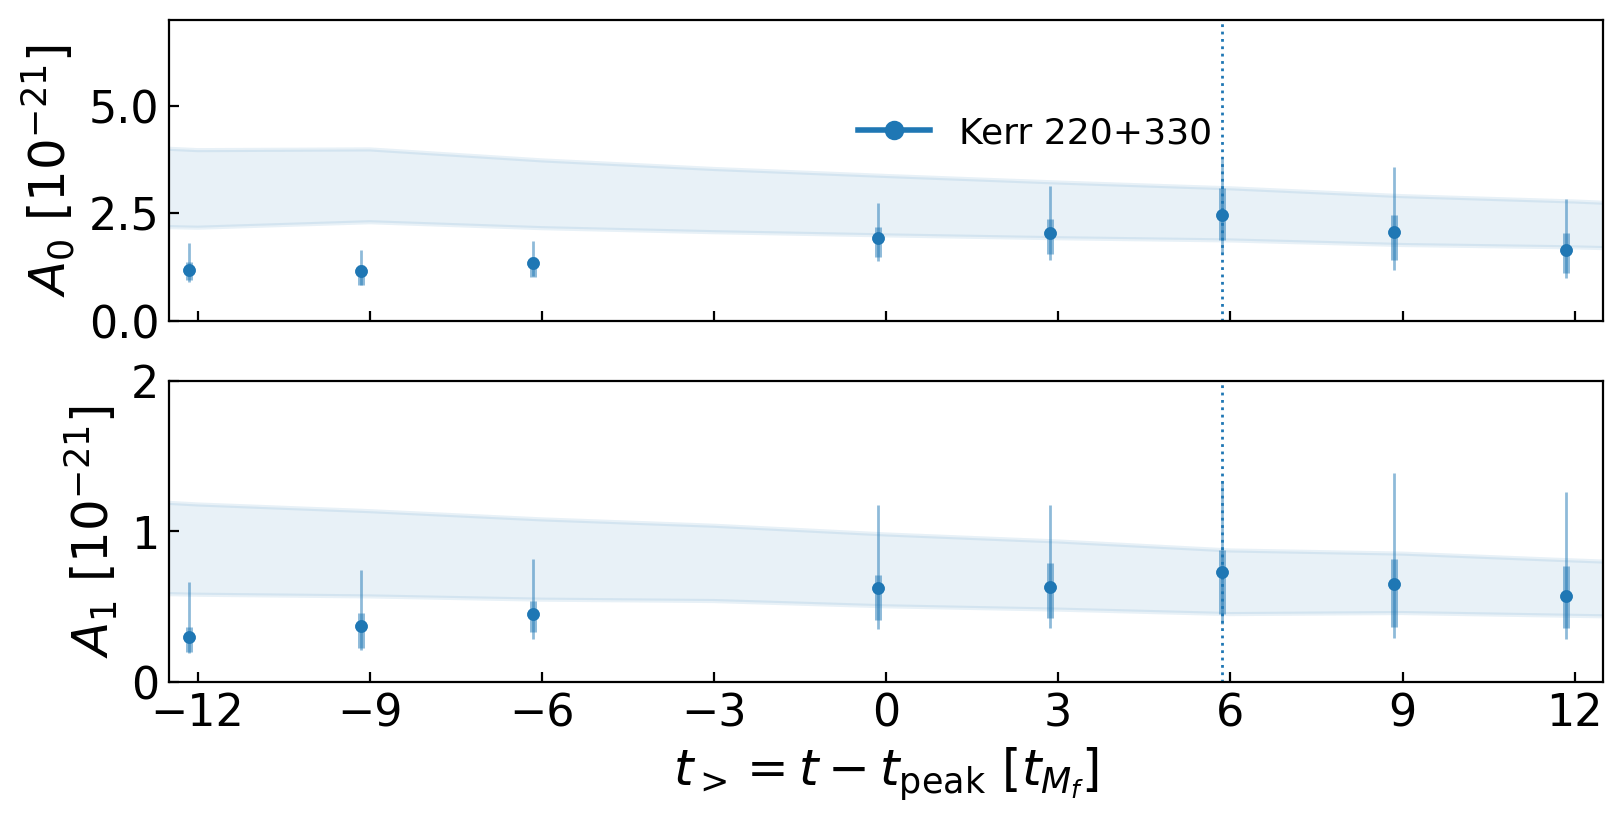

In [186]:
combo = '220+330'
dfs = {combo: df_full[df_full['f_330'] > 60]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+330': 6}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0, np.floor(mode_a_maxes[i]))
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

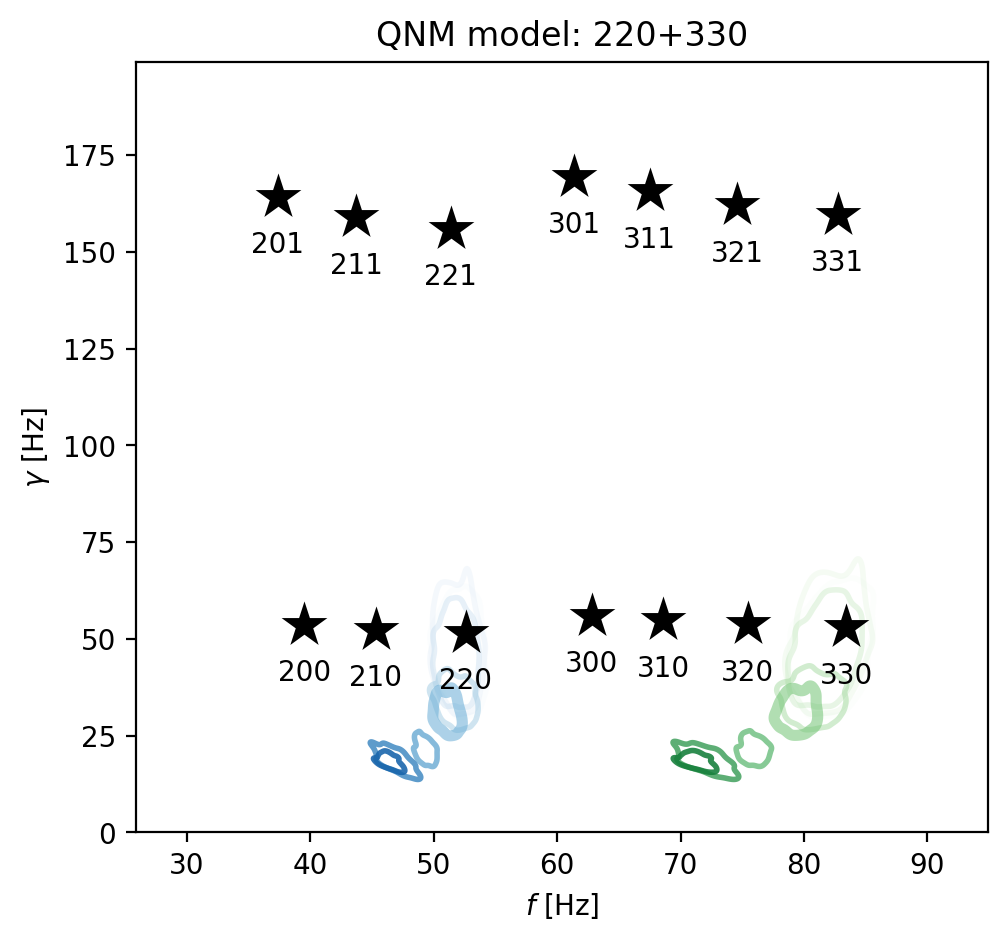

In [161]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

<Axes: xlabel='f_330', ylabel='g_330'>

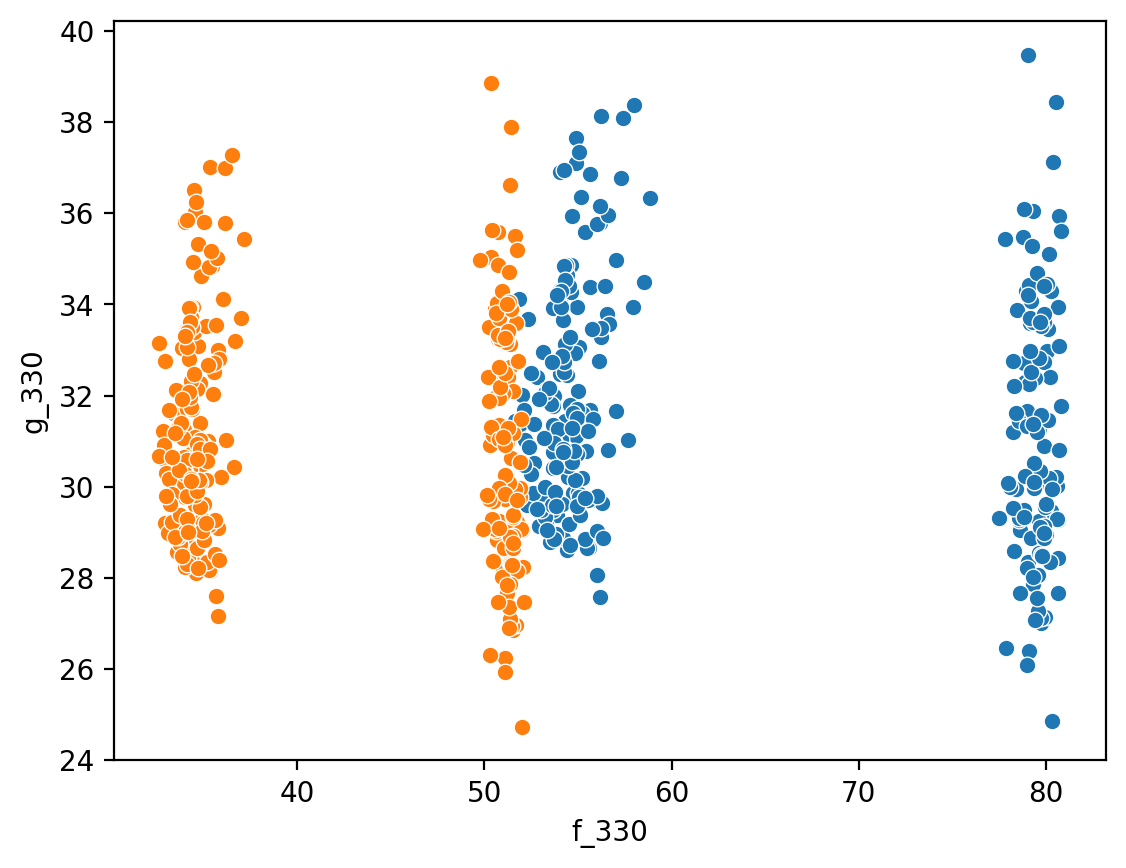

In [164]:
sns.scatterplot(df_full[df_full['run'] == 0], x='f_330', y='g_330')
sns.scatterplot(df_full[df_full['run'] == 0], x='f_220', y='g_220')

### 220+330 light

In [165]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined_light/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [166]:
run = 'SXS_BBH_1156/mtot72/linesub/220+330_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [167]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [168]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [169]:
mf_true = 70.0882137
cf_true = 0.67721823

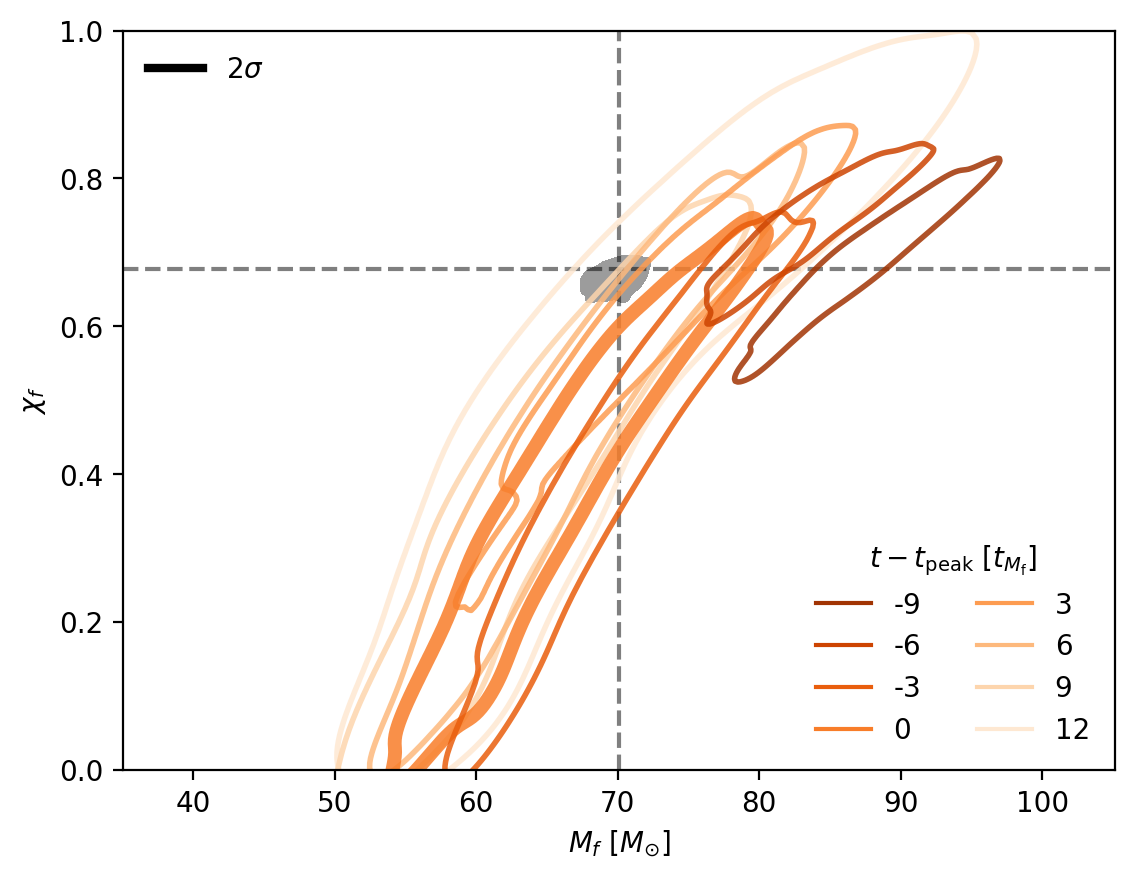

In [170]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[df_full['f_330'] > 300], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
# ax.set_xlim(250, 550)

[9.00449236e-22 4.86209562e-23]
{'220+330': 3}
2


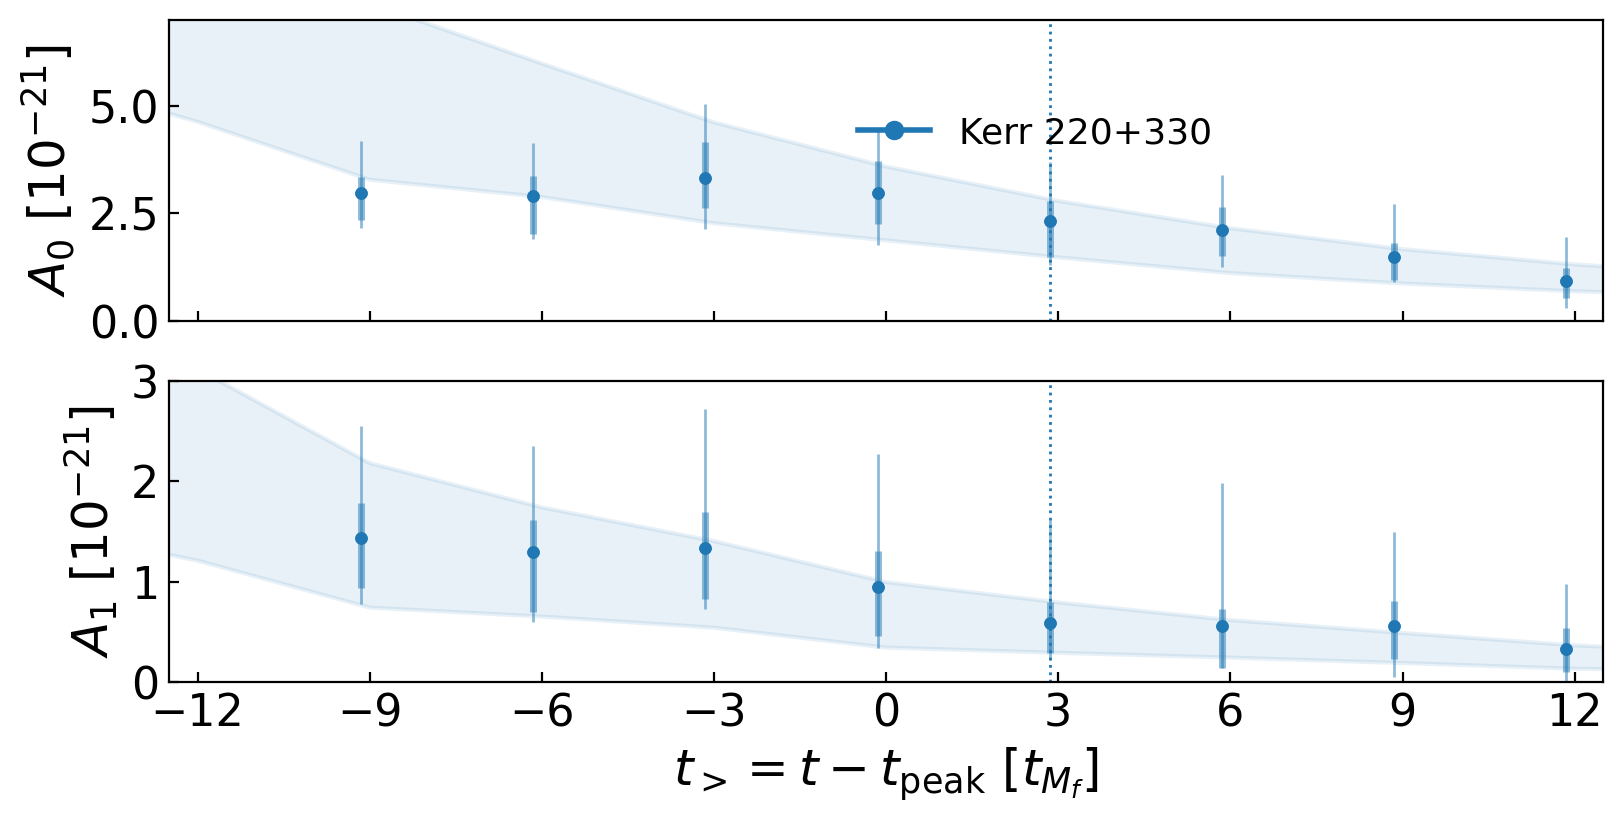

In [174]:
combo = '220+330'
dfs = {combo: df_full[df_full['f_330'] > 300]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+330': 3}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0, np.floor(mode_a_maxes[i]))
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

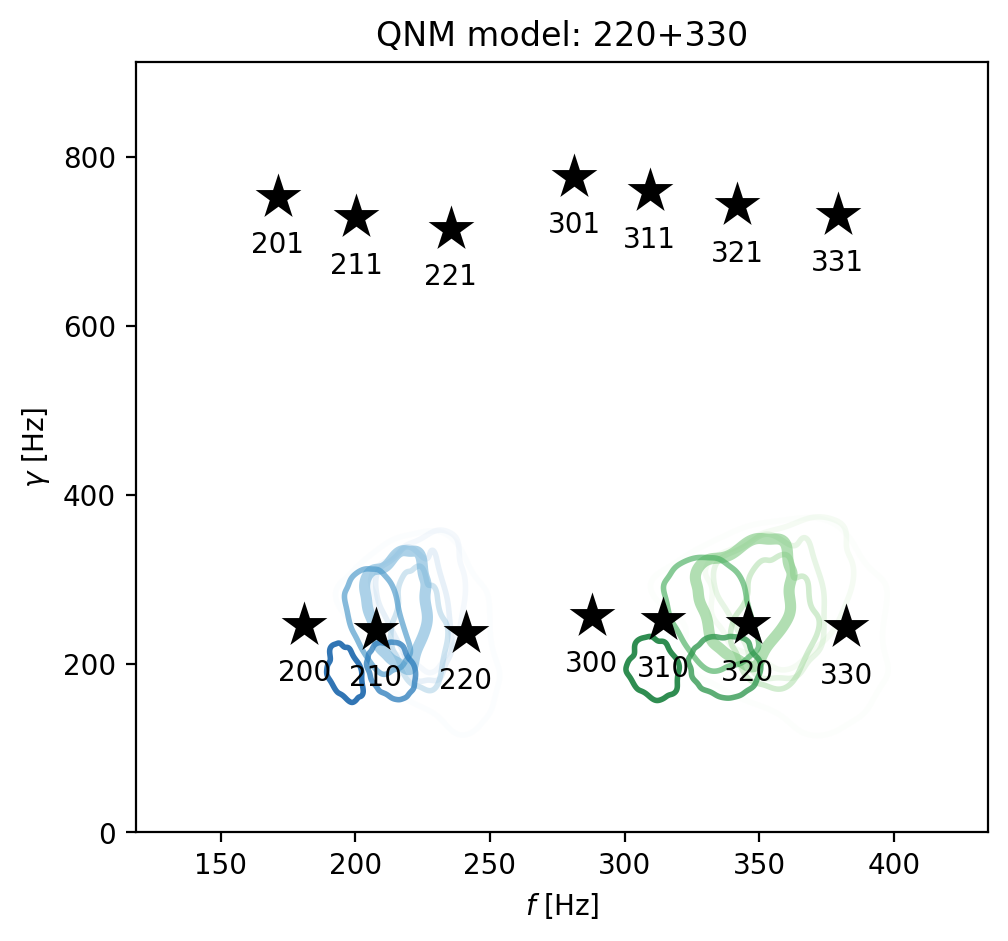

In [25]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

### 220+221+330

In [133]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [134]:
run = 'SXS_BBH_1156/mtot330/linesub/220+221+330_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [135]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [136]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [137]:
mf_true = 321.23764612
cf_true = 0.67721823

(250.0, 550.0)

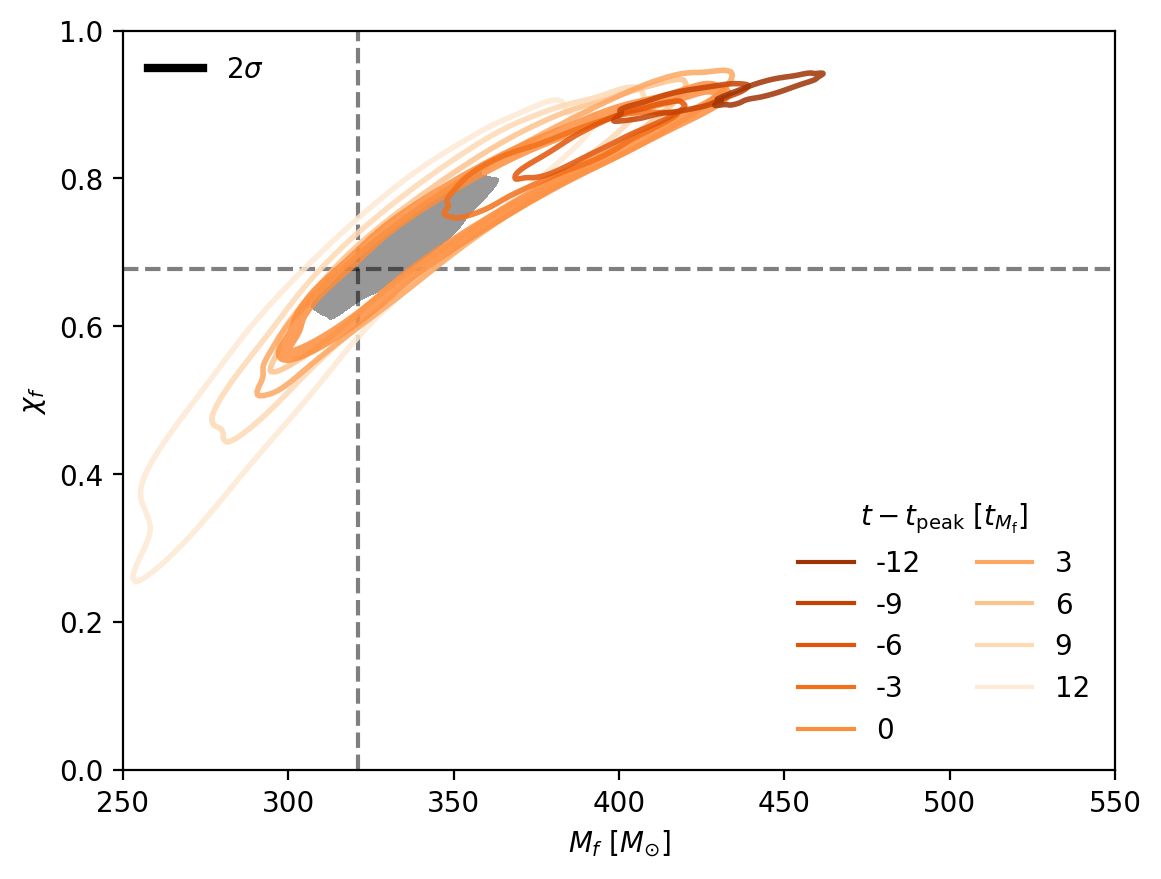

In [138]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[df_full['f_330'] > 60], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
ax.set_xlim(250, 550)

<Axes: xlabel='m', ylabel='chi'>

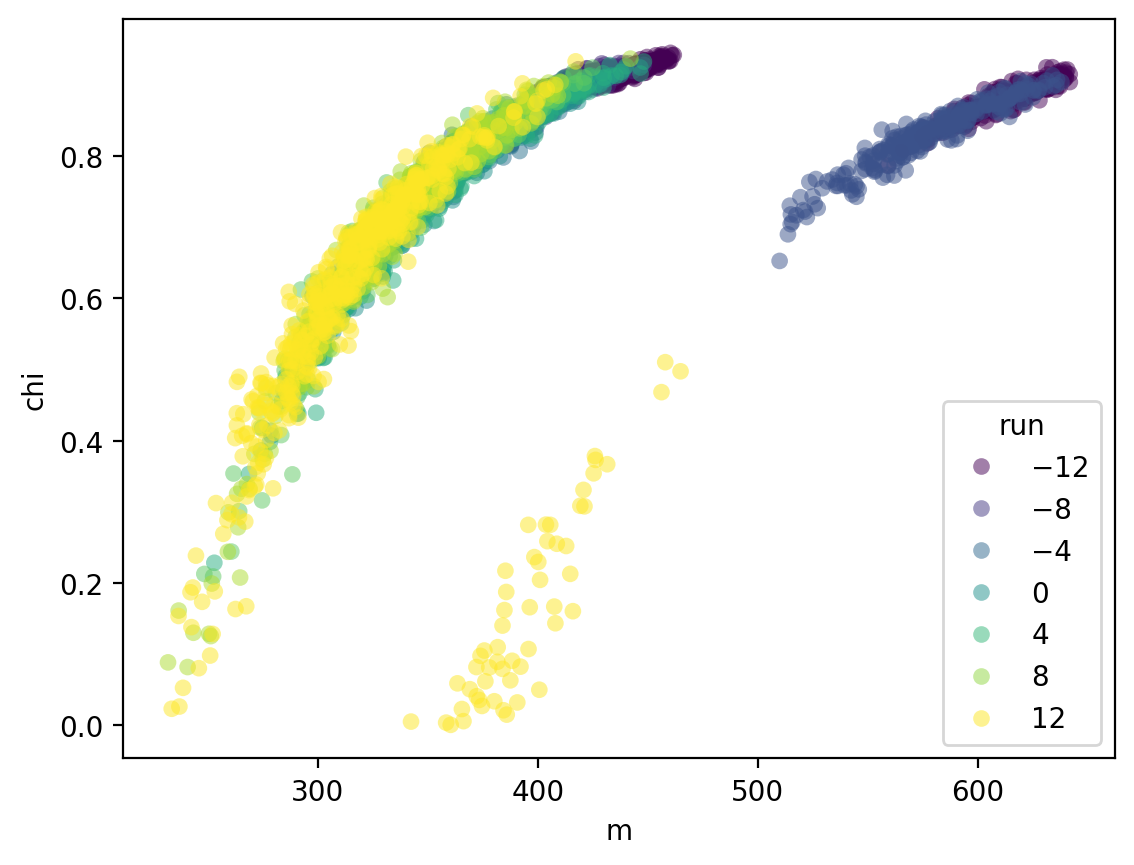

In [139]:
sns.scatterplot(df_full, x='m', y='chi', hue='run', palette='viridis', lw=0, alpha=0.5)
# plt.axvline(550)

[1.50302404e-21 2.42017287e-24 4.04023631e-22]
{'220+221+330': 0}
3


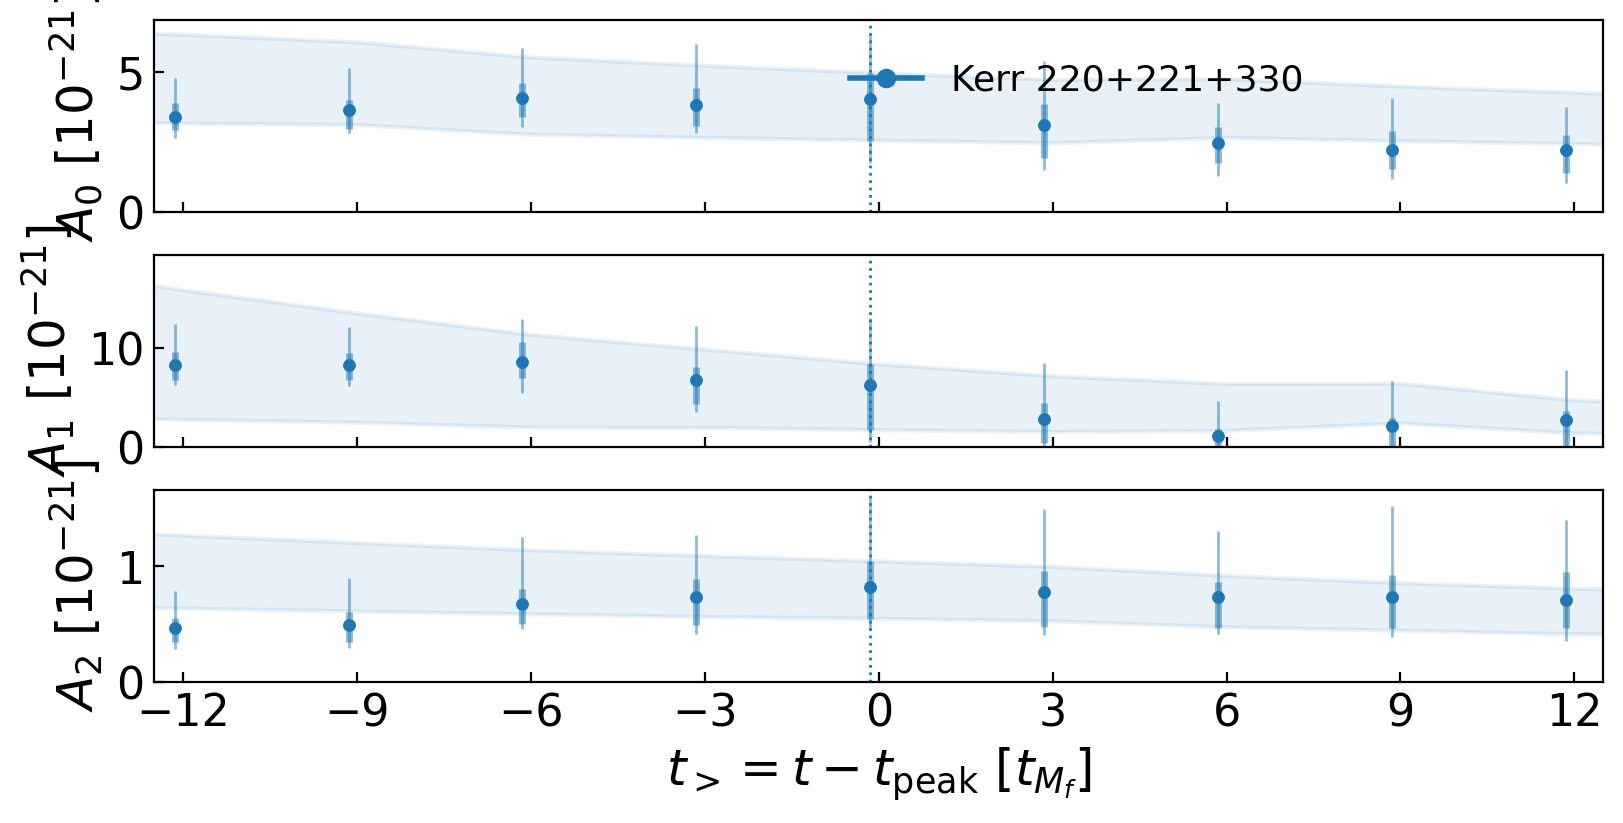

In [129]:
combo = '220+221+330'
dfs = {combo: df_full[df_full['f_330'] > 60]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+221+330': 0}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0)
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

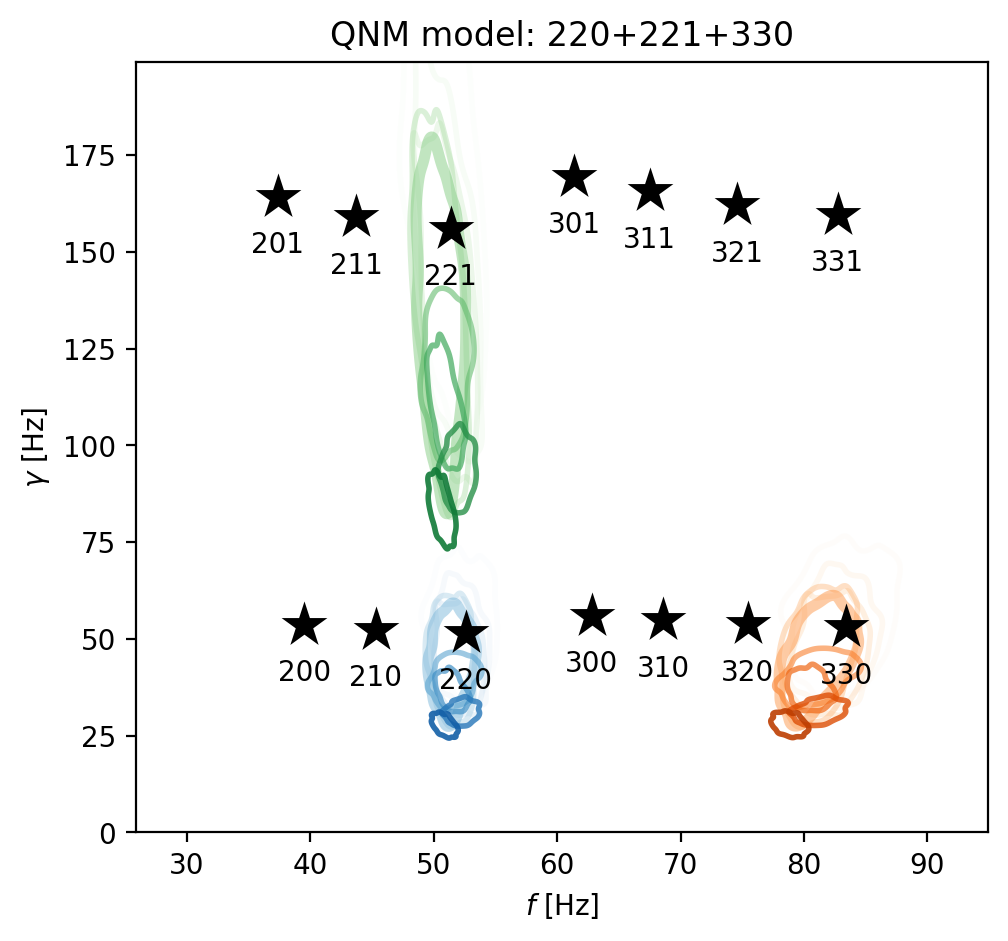

In [128]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

<Axes: xlabel='f_330', ylabel='g_330'>

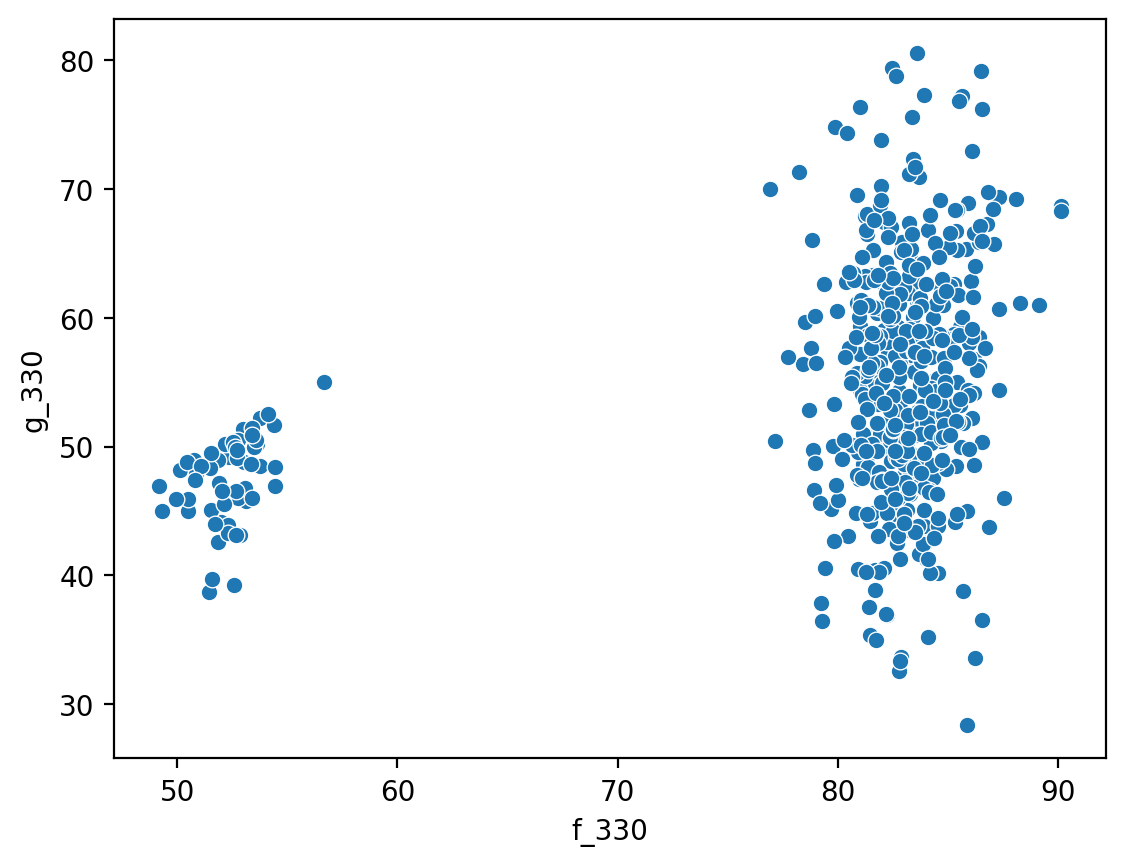

In [83]:
sns.scatterplot(df_full[df_full['run'] == 12], x='f_330', y='g_330')

### 220+221+330 light

In [187]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined_light/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [188]:
run = 'SXS_BBH_1156/mtot72/linesub/220+221+330_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_inclined'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [189]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [190]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [191]:
mf_true = 70.0882137
cf_true = 0.67721823

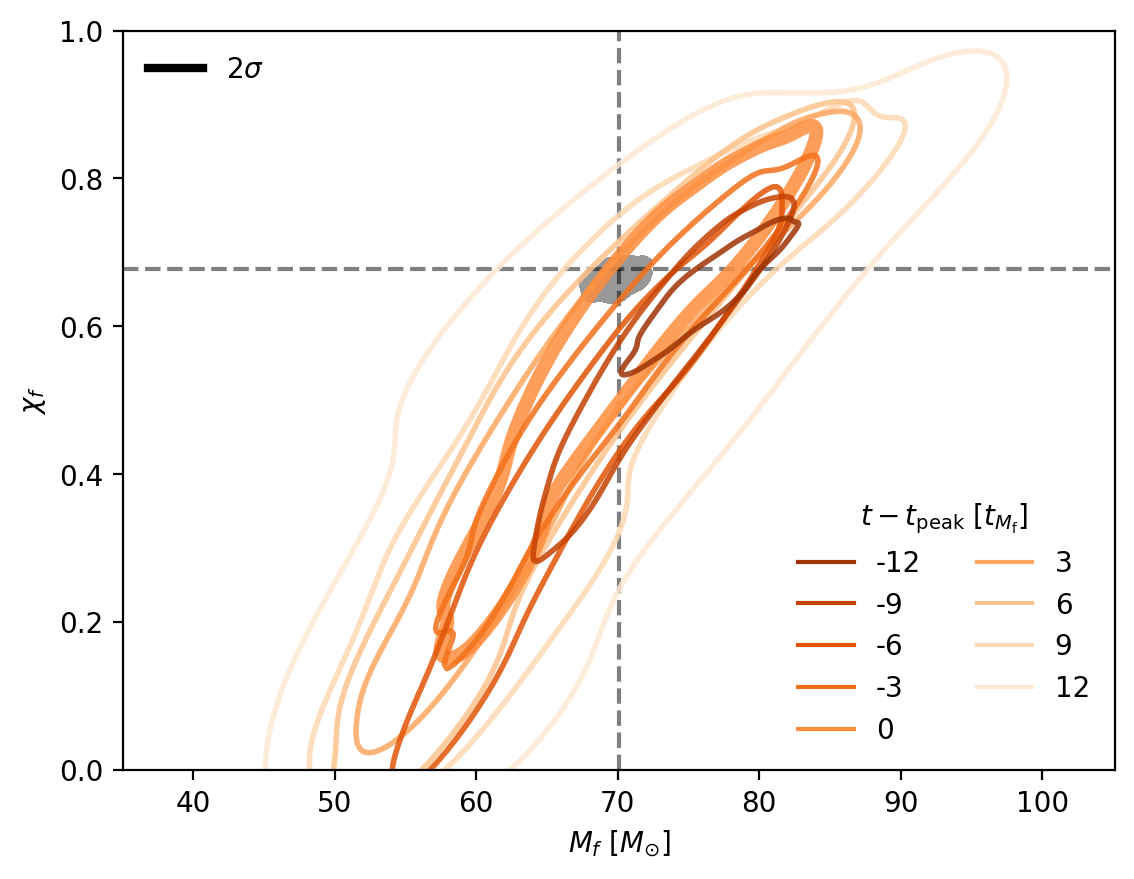

In [192]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[df_full['f_330'] > 300], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
# ax.set_xlim(250, 550)

[1.65653170e-21 4.13984345e-23 3.76451073e-22]
{'220+221+330': 0}
3


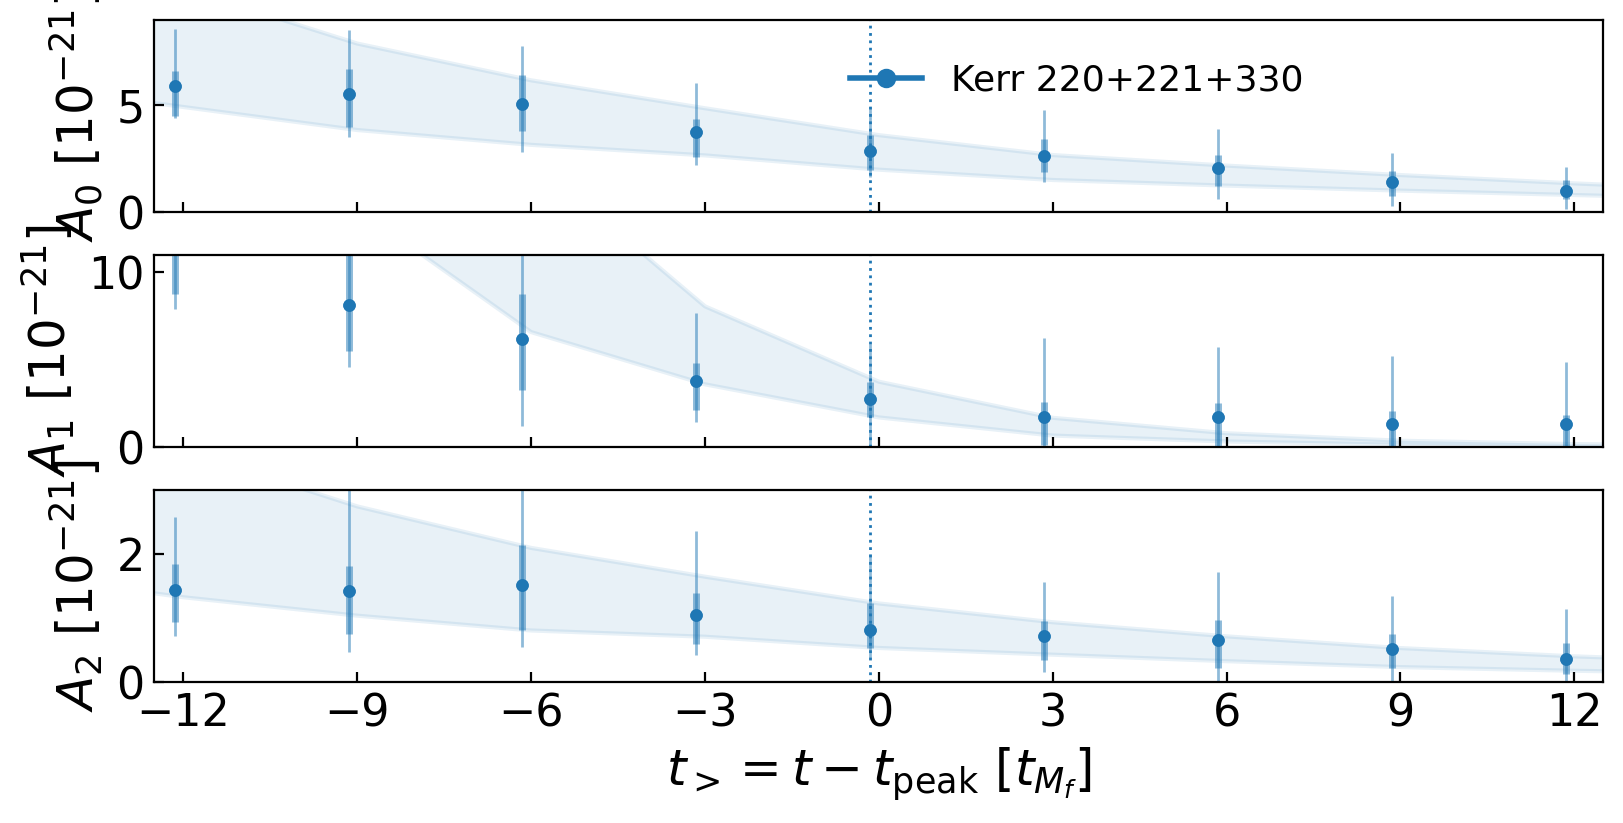

In [193]:
combo = '220+221+330'
dfs = {combo: df_full[df_full['f_330'] > 300]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+221+330': 0}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0, np.floor(mode_a_maxes[i]))
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

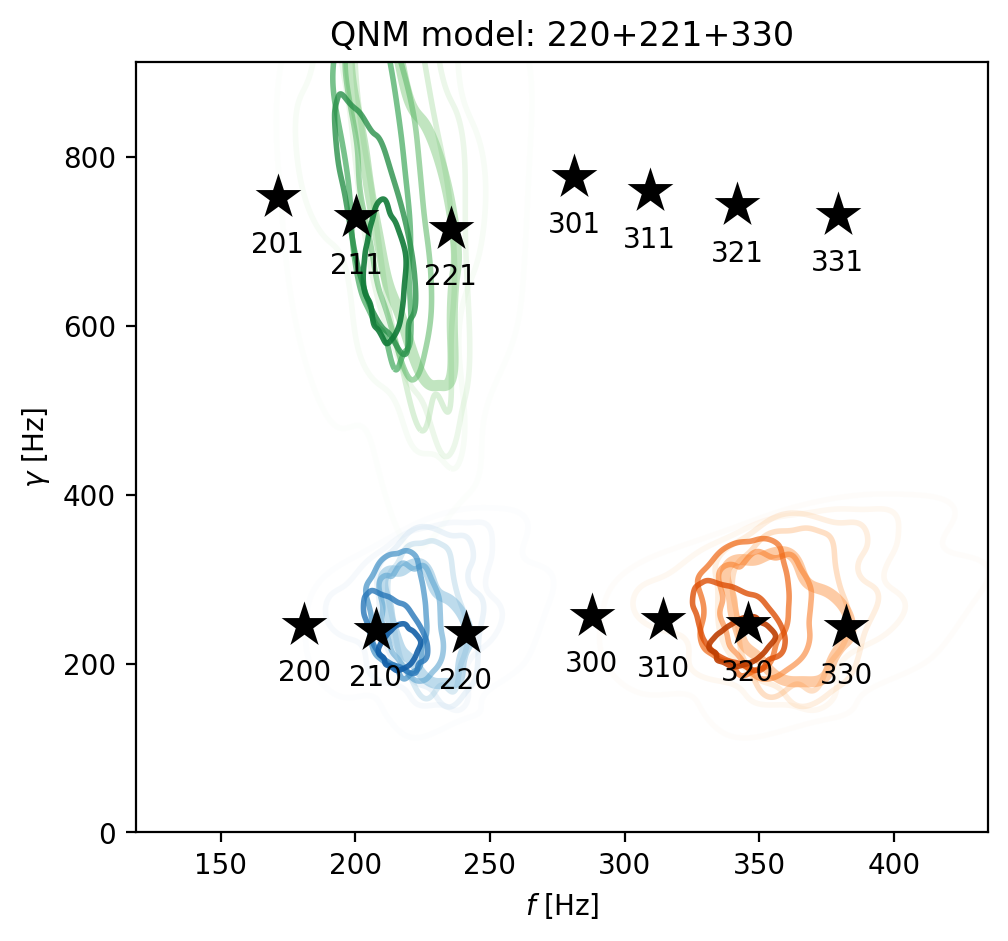

In [115]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

### 220+221+210

In [194]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [195]:
run = 'SXS_BBH_1156/mtot330/linesub/220+221+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [196]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [197]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [198]:
mf_true = 321.23764612
cf_true = 0.67721823

(200.0, 450.0)

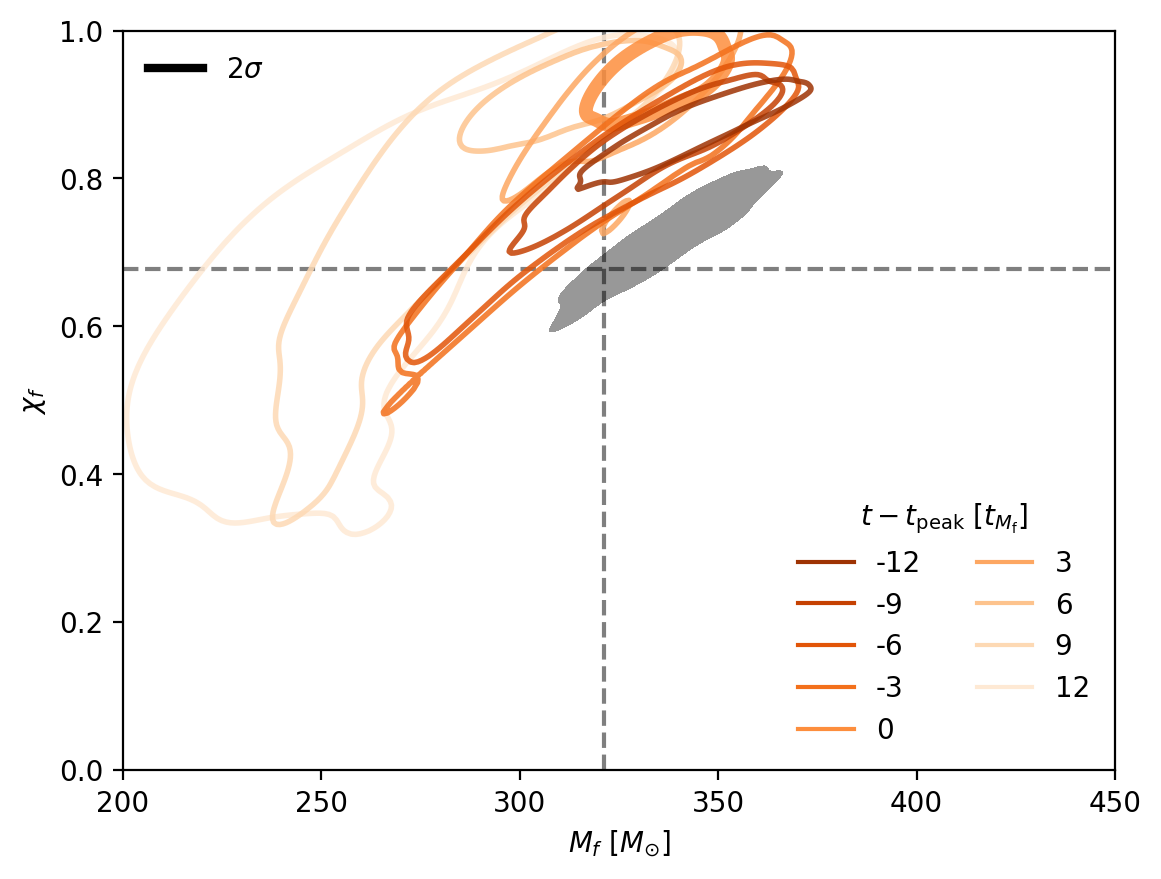

In [207]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[df_full['chi'] >= 0.3], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
ax.set_xlim(200, 450)

[5.94843057e-22 6.93055105e-24 1.85250716e-21]
{'220+221+210': -6}
3


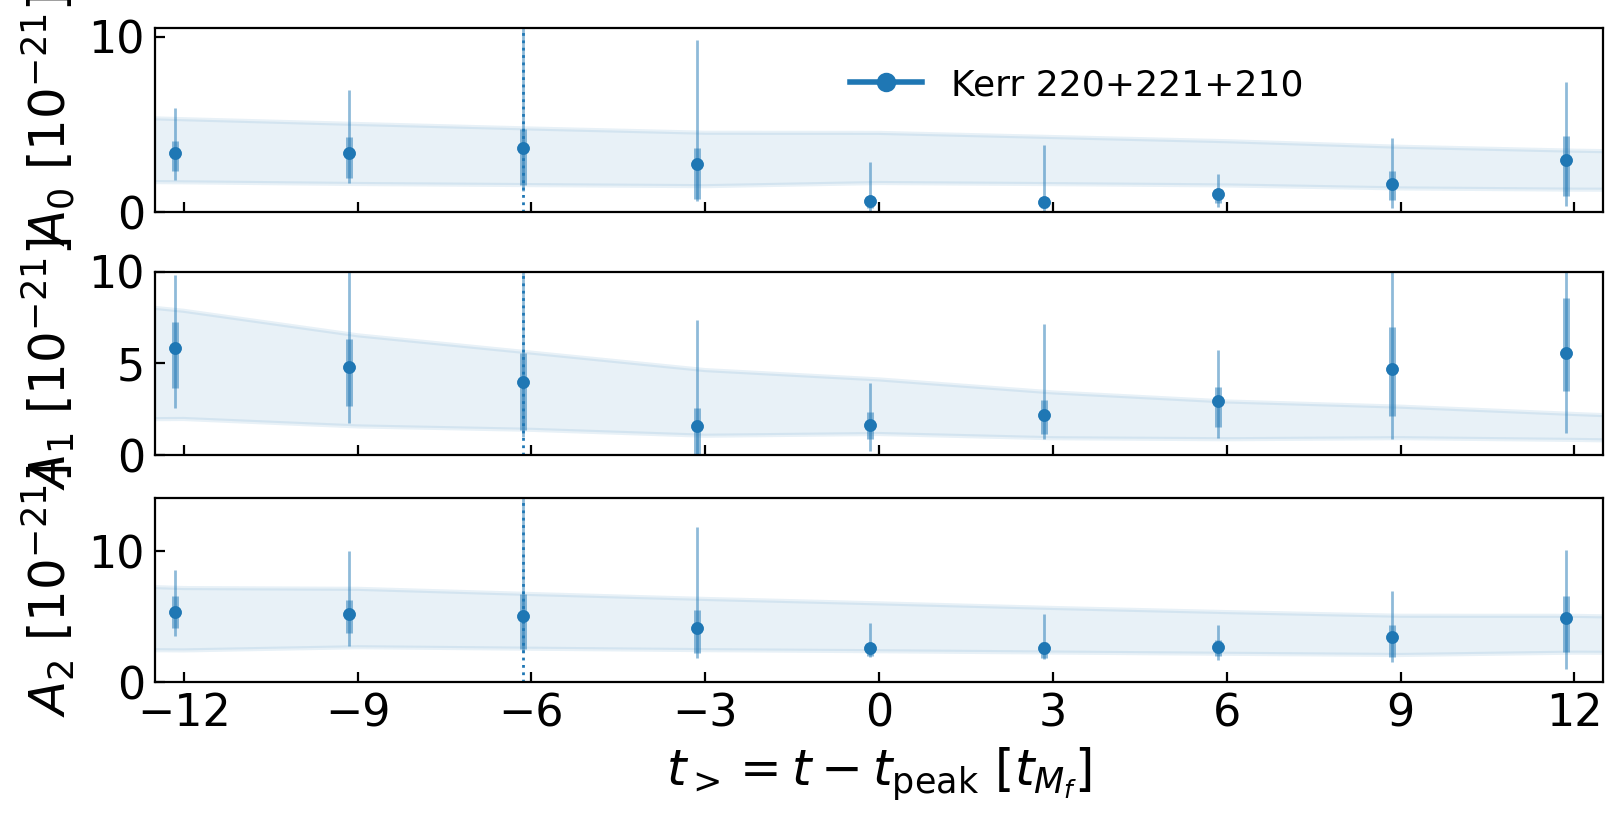

In [222]:
combo = '220+221+210'
dfs = {combo: df_full[df_full['chi'] > 0.3]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+221+210': -6}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0, np.floor(mode_a_maxes[i])/2)
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

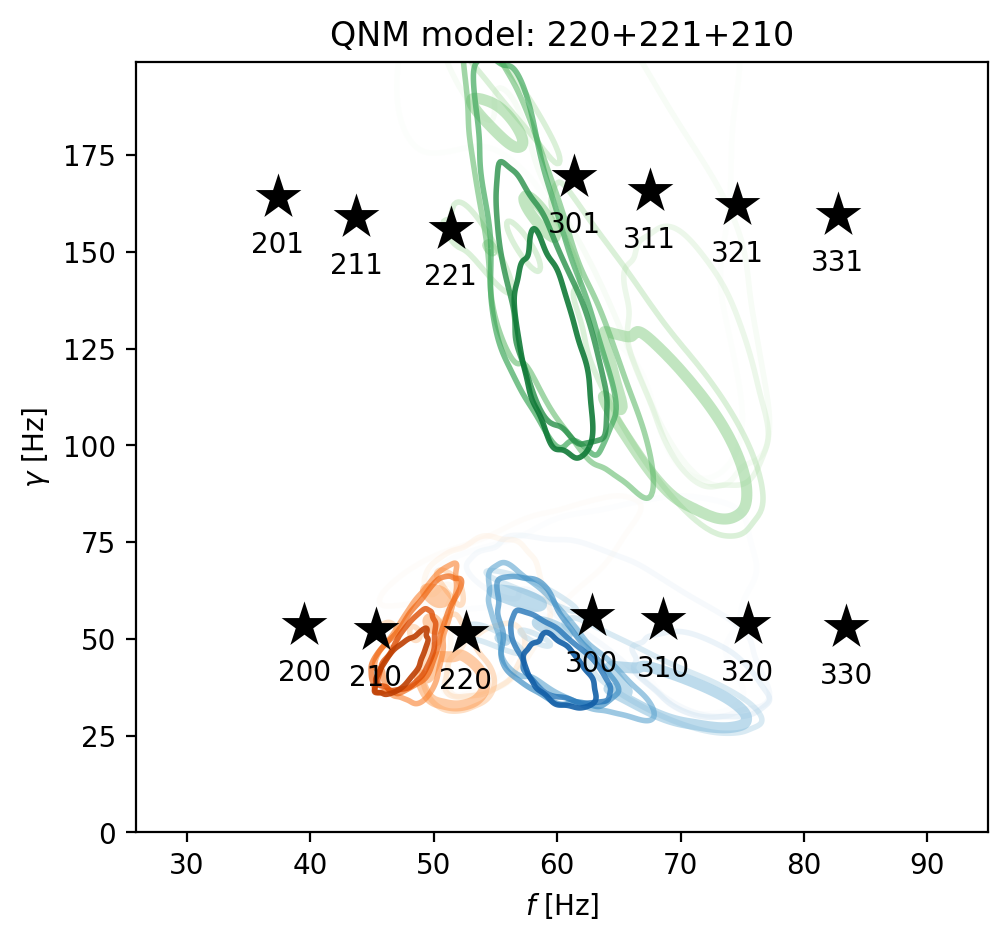

In [223]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

<Axes: xlabel='f_221', ylabel='g_221'>

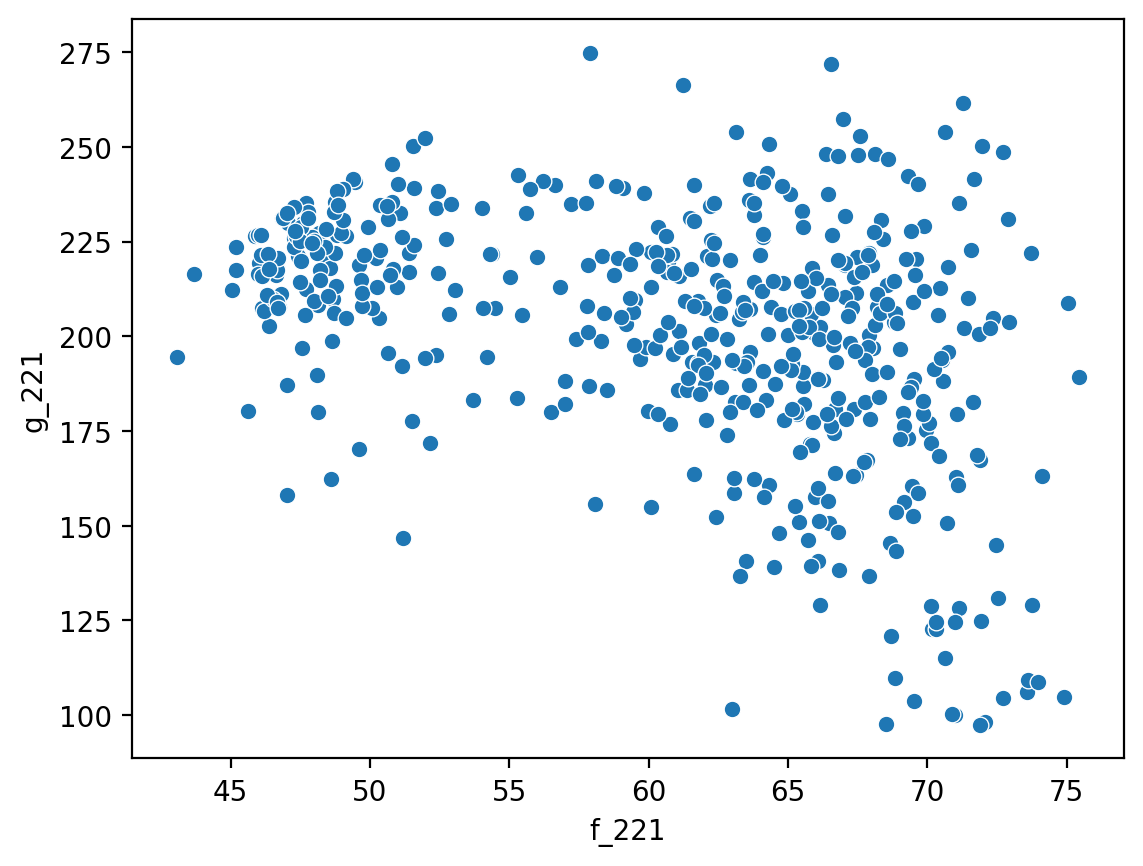

In [232]:
sns.scatterplot(df_full[df_full['run'] == 12], x='f_221', y='g_221')

### 220+210

In [233]:
with h5py.File('/mnt/home/nkhusid/src/NRInjections_PE/runs/SXS_BBH_1156_inclined/result/summarypages/samples/posterior_samples.h5', 'r') as f:
    pe_df = pd.DataFrame(np.array(f['NRSur7dq4']['posterior_samples']))

In [234]:
run = 'SXS_BBH_1156/mtot330/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined'
coll = rd.ResultCollection.from_netcdf(f'{str(dirs.resdir / run)}/engine/*/result.nc')

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [235]:
coll.reindex_by_t0(reference_time=1126259462.423, reference_mass=coll[0].config['model']['m_min'] * 2, decimals=0)

In [236]:
df_full = coll.get_parameter_dataframe(ndraw=500, progress=True, prng=13)

results:   0%|          | 0/9 [00:00<?, ?it/s]

In [237]:
mf_true = 321.23764612
cf_true = 0.67721823

(200.0, 450.0)

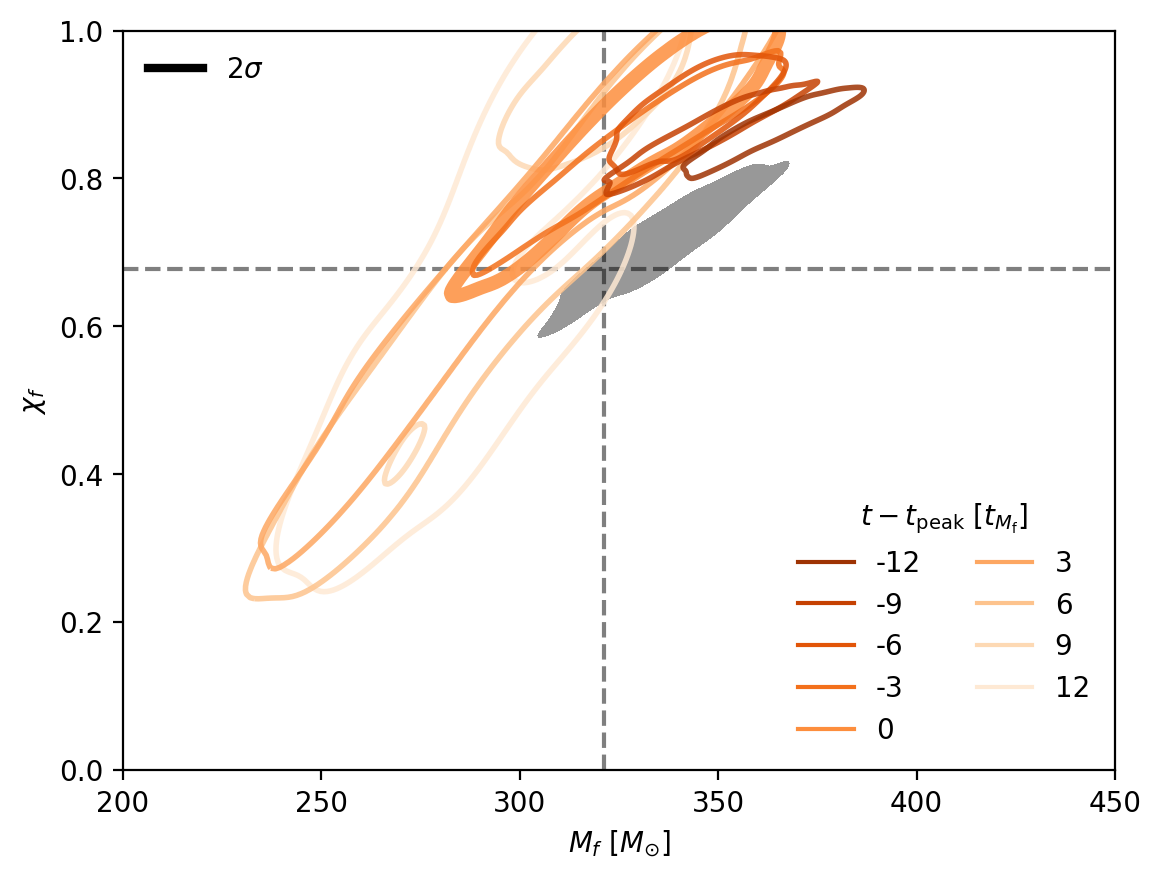

In [238]:
fig, ax = plt.subplots()
pu.plot_mfcf_man(df_full[df_full['chi'] >= 0.3], mf_true, cf_true, ax, pe_df=pe_df, **dict(palette='Oranges_r'))
ax.set_xlim(200, 450)

[5.94843057e-22 6.93055105e-24 1.85250716e-21]
{'220+221+210': -6}
3


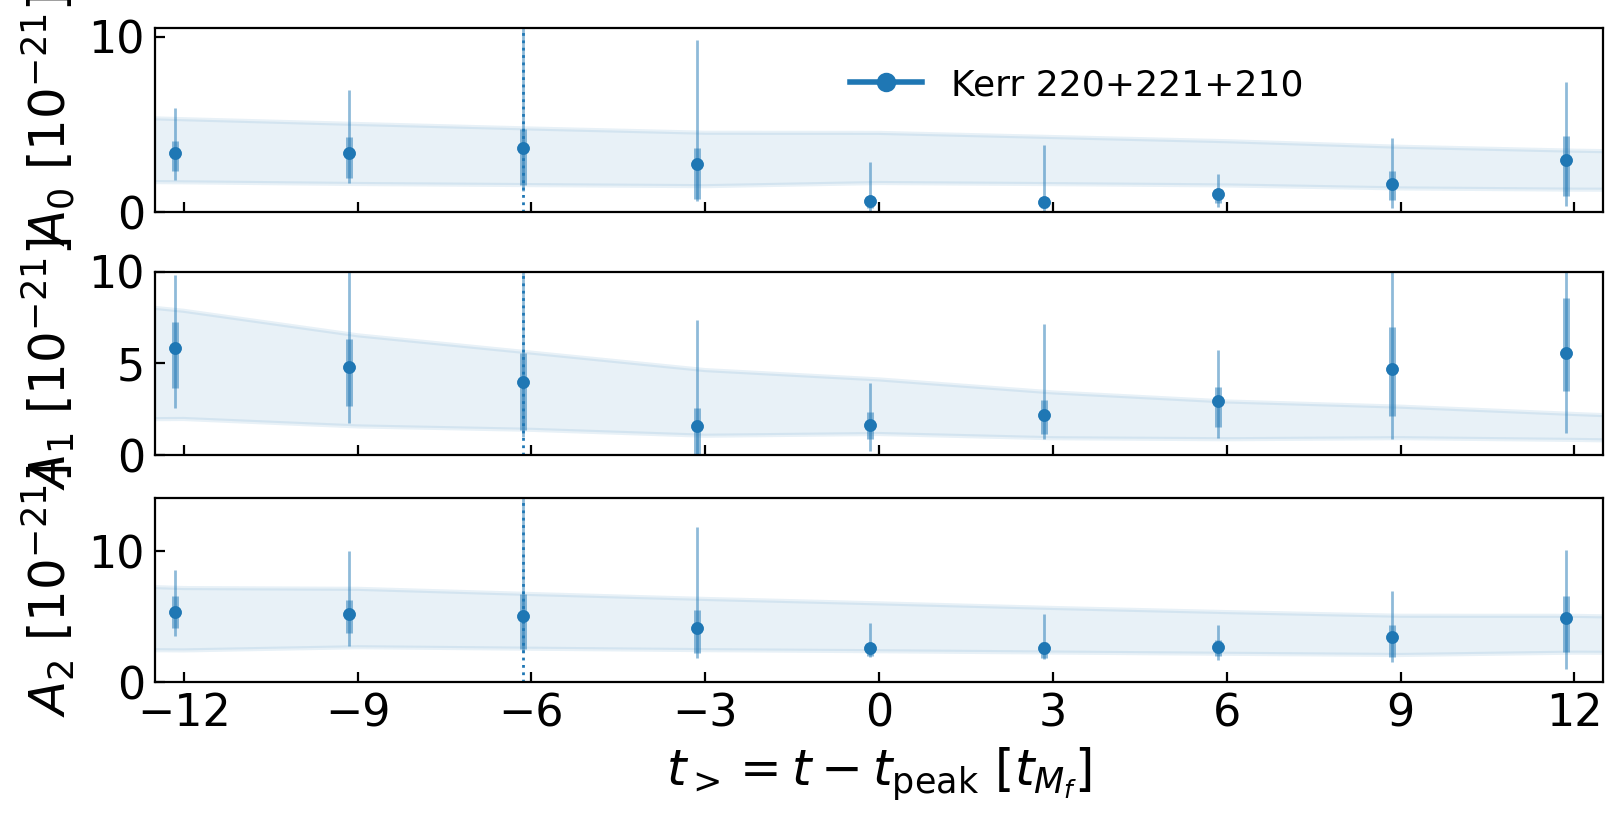

In [ ]:
combo = '220+221+210'
dfs = {combo: df_full[df_full['chi'] > 0.3]}
trefs = {}

for combo, df in dfs.items():
    ts = df['run'].unique()
    modes = combo.split('+')
    for i, start in enumerate(ts):
        # print(start)
        start_df = df[df['run'] == start]
        a_lo = np.array([az.hdi(start_df[f'a_{mode}'].values, 0.95)[0] for mode in modes])
        # print(a_lo)
        if np.all(a_lo > 1e-22):
            if start == max(ts):
                print(a_lo)
                trefs[combo] = start
                break
            else:
                pass
        else:
            print(a_lo)
            trefs[combo] = ts[i-1]
            break

trefs = {'220+221+210': -6}

print(trefs)

a_dfs = {combo: {mode: pu.get_projection(dfs[combo], mode, tref) for mode in combo.split('+')} for combo, tref in trefs.items()}

# a_true_df = {mode: get_projection(dfs[combo_true], mode, tref) for mode in modes_true}

nrows = max([len(combo.split('+')) for combo in a_dfs.keys()])
print(nrows)

fig, ax = plt.subplots(nrows, 1, figsize=(8, 4), layout='constrained', sharex=True)

clevs = [0.95, 0.68]

mode_a_scales = {}
mode_a_maxes = {}
ref_a_scale = 1e-21
ref_loga_scales = np.ones((len(dfs),)) * np.log10(ref_a_scale)
for i in range(nrows):
    loga_scales = np.array([np.floor(np.log10(np.median(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values))) if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    if (loga_scales > ref_loga_scales).any():
        mode_a_scales[i] = 10 ** max(loga_scales[loga_scales > ref_loga_scales])
    else:
        mode_a_scales[i] = ref_a_scale

    a_maxes = np.array([az.hdi(df[df['run'] == trefs[combo]][f"a_{combo.split('+')[i]}"].values, max(clevs))[1] * 2 if len(combo.split('+')) > i else -100 for combo, df in dfs.items()])
    mode_a_maxes[i] = max(a_maxes) / mode_a_scales[i]

if type(ax) is not np.ndarray:
    ax = [ax]

ax[len(ax)-1].set_xlabel('$t_> = t - t_{\\mathrm{peak}}$ [$t_{M_f}$]', fontsize=18)
ax[len(ax)-1].set_xticks(np.arange(-12, 15, 3))

legend_handles = []
for mark, (combo, df) in enumerate(dfs.items()):
    c = f'C{mark}'

    for i, mode in enumerate(combo.split('+')):
        # if i < len(modes_true):
        shift = np.linspace(-0.15, 0.15, len([df]))[mark]
        pu.plot_scan(df, mode, clevs, c, ax[i], marker='o', shift=shift, a_scale=mode_a_scales[i])
        pu.plot_projection(a_dfs[combo][mode], [min(clevs)], ax[i], color=c, a_scale=mode_a_scales[i])
        ax[i].axvline(trefs[combo]+shift, ls=':', lw=1, color=c)

        ax[i].set_ylabel(f'$A_{{{i}}}$ [$10^{{{int(np.log10(mode_a_scales[i]))}}}$]', fontsize=18)
        ax[i].set_xlim(-12.5, 12.5)
        ax[i].set_ylim(0, np.floor(mode_a_maxes[i])/2)
        ax[i].tick_params(axis='both', labelsize=16, direction='in')

    legend_handles.append(plt.Line2D([0, 0], [0, 1], color=c, marker='o', 
                                    linestyle='-', linewidth=2, label='Kerr '+combo, 
                                    markerfacecolor=c, markeredgecolor=c))

leg = ax[0].legend(handles=legend_handles, loc=(0.47, 0.52), frameon=False, ncol=2, fontsize=13)

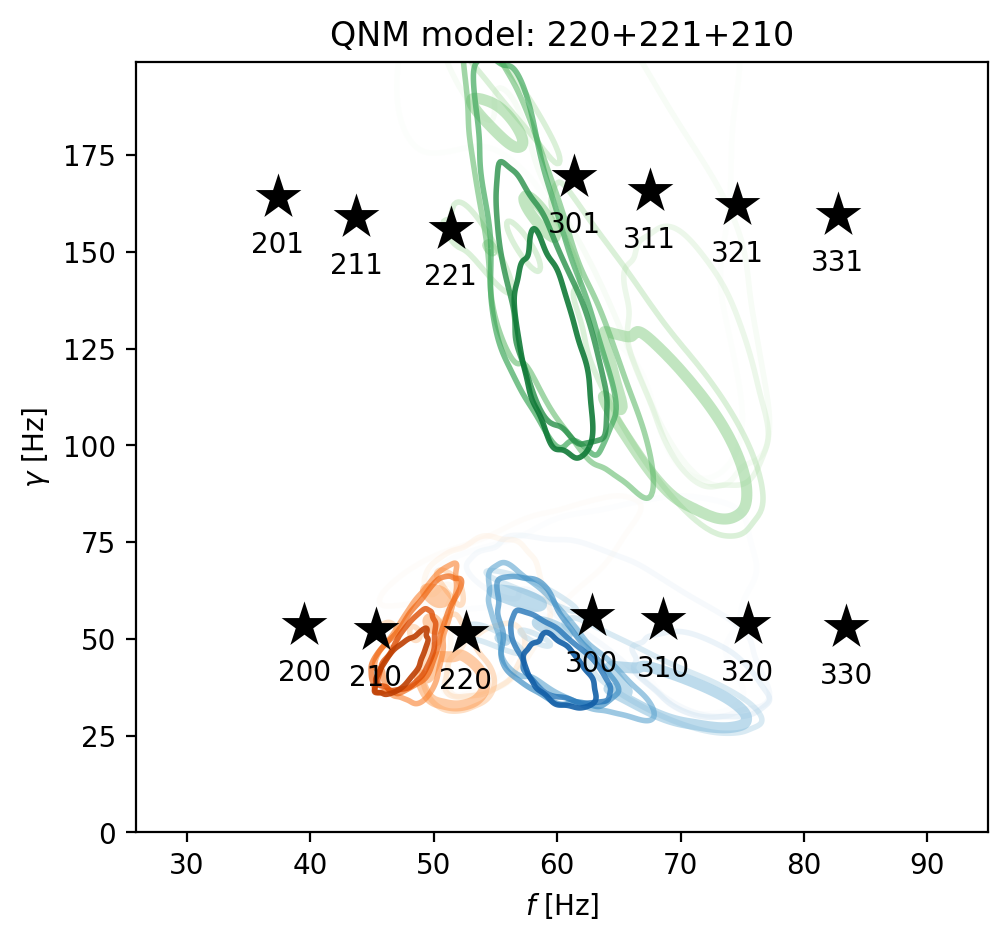

In [ ]:
fs = {}
gs = {}

### finding the frequencies and damping rates of each mode ###
for l in [2, 3]: 
    for m in range(l+1):
        for n in [0, 1]:
            f, tau = rd.qnms.get_ftau(mf_true, cf_true, l=l, m=m, n=n)
            fs[(l,m,n)] = f
            gs[(l,m,n)] = 1/tau

# Kerr results
fig, ax = plt.subplots(1, len(dfs), figsize=((11*1.5)/3*len(dfs), 5), sharex=True, sharey=True)
if len(dfs) == 1:
    ax = [ax]

for i, (combo, df) in enumerate(dfs.items()):
    legend = True
    if i != 0:
        legend = False
    pu.plot_fg_man(df, combo.split('+'), fs, gs, ax[i], legend=legend)
    ax[i].set_title(f'QNM model: {combo}')

<Axes: xlabel='f_210', ylabel='g_210'>

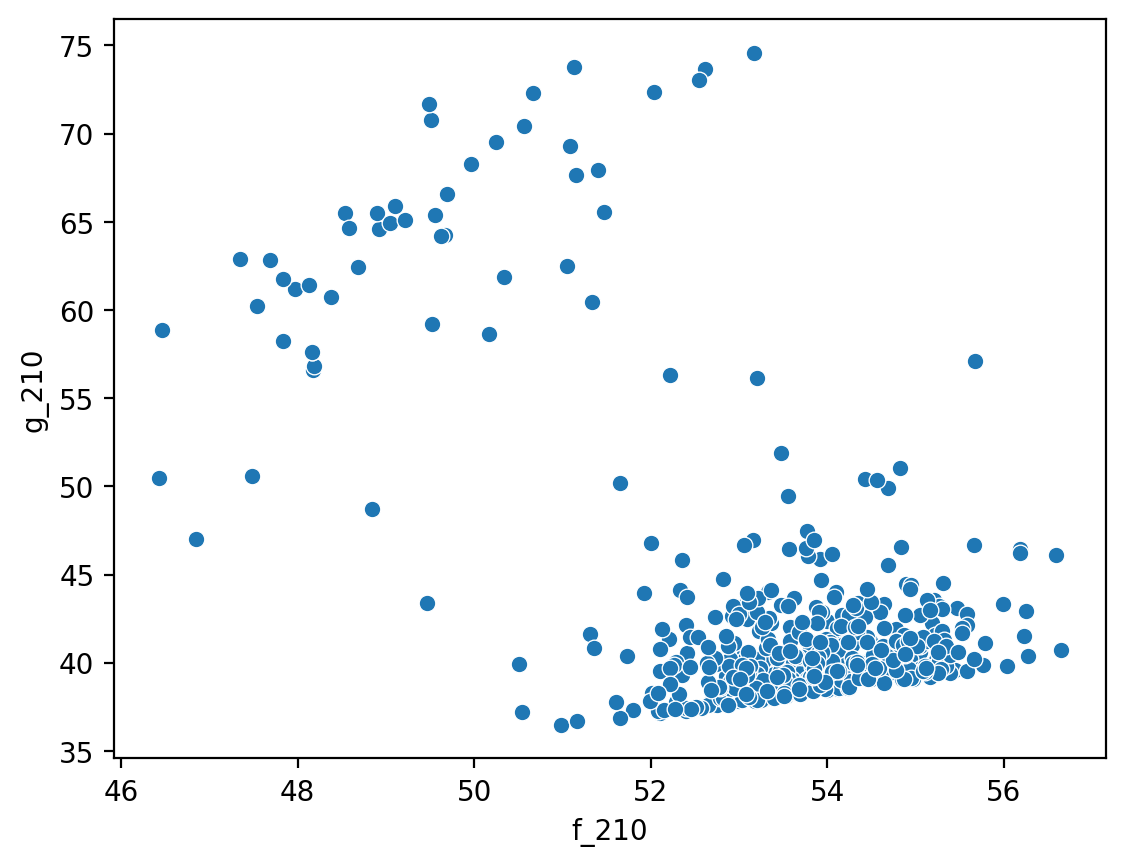

In [240]:
sns.scatterplot(df_full[df_full['run'] == 9], x='f_210', y='g_210')